<a href="https://colab.research.google.com/github/knguyen0923/Equi-Metrics/blob/main/Equi_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Librarires

In [ ]:
import pandas as pd
import requests
from sklearn.model_selection import train_test_split
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import os
from google.colab import drive

# Mounting it onto google drive

In [ ]:
# Ensure the mount point is empty before mounting
if os.path.exists('/content/drive'):
    # Only remove contents if it's a directory and not already mounted
    if os.path.isdir('/content/drive') and not os.path.ismount('/content/drive'):
        print("Clearing existing content in /content/drive...")
        for item in os.listdir('/content/drive'):
            item_path = os.path.join('/content/drive', item)
            if os.path.isfile(item_path):
                os.remove(item_path)
            elif os.path.isdir(item_path):
                os.system(f'rm -rf {item_path}') # Use rm -rf for directories

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Create folders for datasets in drive if notebook closes

In [ ]:
import os

base_path = "/content/drive/MyDrive/EquiMetrics"

folders = [
    "raw_data",
    "clean_data",
    "training_data",
    "testing_data",
    "models"
]

for folder in folders:
    os.makedirs(f"{base_path}/{folder}", exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


# Store API Key


In [ ]:
os.environ["RACING_API_KEY"] = "BCSw6ATaJLmgZGM07my7H2Hx"

# Test the API

In [ ]:
api_key = os.getenv("RACING_API_KEY")

import requests
from requests.auth import HTTPBasicAuth

url = "https://api.theracingapi.com/v1/courses/regions"
params = {}
response = requests.request("GET", url, auth=HTTPBasicAuth('BCSw6ATaJLmgZGM07my7H2Hx','QshgVJBr3t5DjjIc7mN3hNoI'), params=params)
print(response.json())

[{'region': 'Argentina', 'region_code': 'arg'}, {'region': 'Austria', 'region_code': 'aut'}, {'region': 'Denmark', 'region_code': 'den'}, {'region': 'India', 'region_code': 'ind'}, {'region': 'Sweden', 'region_code': 'swe'}, {'region': 'Great Britain', 'region_code': 'gb'}, {'region': 'USA', 'region_code': 'usa'}, {'region': 'Malaysia', 'region_code': 'mal'}, {'region': 'Qatar', 'region_code': 'qa'}, {'region': 'Greece', 'region_code': 'gr'}, {'region': 'Peru', 'region_code': 'per'}, {'region': 'Morocco', 'region_code': 'mor'}, {'region': 'Hungary', 'region_code': 'hun'}, {'region': 'China', 'region_code': 'chn'}, {'region': 'Poland', 'region_code': 'pol'}, {'region': 'Macau', 'region_code': 'mac'}, {'region': 'Norway', 'region_code': 'nor'}, {'region': 'Cyprus', 'region_code': 'cyp'}, {'region': 'Israel', 'region_code': 'isr'}, {'region': 'Barbados', 'region_code': 'bar'}, {'region': 'Germany', 'region_code': 'ger'}, {'region': 'Ireland', 'region_code': 'ire'}, {'region': 'Italy', 're

I was able to manually download the CSV file from May 26 2025 - May 26 2026 and got over 160k lines

In [ ]:
#Load CSV
df = pd.read_csv("/content/drive/MyDrive/EquiMetrics/raw_data/racingapidata.csv")


# Check Shape

In [ ]:
print("Shape:")
print(df.shape)

Shape:
(168407, 65)


# Print Head

In [ ]:
print("First 5 rows")
print(df.head())

First 5 rows
   race_race_id   race_date race_region            race_course race_course_id  \
0  rac_11657659  2025-05-26         USA  Churchill Downs (USA)       crs_8008   
1  rac_11657659  2025-05-26         USA  Churchill Downs (USA)       crs_8008   
2  rac_11657659  2025-05-26         USA  Churchill Downs (USA)       crs_8008   
3  rac_11657659  2025-05-26         USA  Churchill Downs (USA)       crs_8008   
4  rac_11657659  2025-05-26         USA  Churchill Downs (USA)       crs_8008   

  race_off                race_off_dt  \
0     9:22  2025-05-26T21:22:00+01:00   
1     9:22  2025-05-26T21:22:00+01:00   
2     9:22  2025-05-26T21:22:00+01:00   
3     9:22  2025-05-26T21:22:00+01:00   
4     9:22  2025-05-26T21:22:00+01:00   

                                      race_race_name race_type race_class  \
0  Winning Colors Stakes  (4yo+ Fillies & Mares) ...      Flat        NaN   
1  Winning Colors Stakes  (4yo+ Fillies & Mares) ...      Flat        NaN   
2  Winning Colors Stak

# Check all Datatypes

In [ ]:
print("Datetypes")
print(df.dtypes)

Datetypes
race_race_id         object
race_date            object
race_region          object
race_course          object
race_course_id       object
                      ...  
runner_dam_id        object
runner_damsire       object
runner_damsire_id    object
runner_comment       object
runner_silk_url      object
Length: 65, dtype: object


# Check missing values

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
race_race_id             0
race_date                0
race_region              0
race_course              0
race_course_id           0
                     ...  
runner_dam_id            3
runner_damsire           6
runner_damsire_id        6
runner_comment       31092
runner_silk_url          0
Length: 65, dtype: int64


# Remove duplicates

In [ ]:
df = df.drop_duplicates()
print(df.shape)

(168407, 65)


# Convert Dates if available

In [ ]:
if "race_date" in df.columns:
  df["race_date"]=pd.to_datetime(df["race_date"])
print(df.shape)

(168407, 65)


# Fill Missing Values

In [ ]:
df = df.fillna(0)
print(df.shape)

(168407, 65)


# Print out all the columns

In [ ]:
print(df.columns)

Index(['race_race_id', 'race_date', 'race_region', 'race_course',
       'race_course_id', 'race_off', 'race_off_dt', 'race_race_name',
       'race_type', 'race_class', 'race_pattern', 'race_rating_band',
       'race_age_band', 'race_sex_rest', 'race_dist', 'race_dist_y',
       'race_dist_m', 'race_dist_f', 'race_going', 'race_surface',
       'race_jumps', 'race_winning_time_detail', 'race_comments',
       'race_non_runners', 'race_tote_win', 'race_tote_pl', 'race_tote_ex',
       'race_tote_csf', 'race_tote_tricast', 'race_tote_trifecta',
       'runner_horse_id', 'runner_horse', 'runner_sp', 'runner_sp_dec',
       'runner_bsp', 'runner_number', 'runner_position', 'runner_draw',
       'runner_btn', 'runner_ovr_btn', 'runner_age', 'runner_sex',
       'runner_weight', 'runner_weight_lbs', 'runner_headgear', 'runner_time',
       'runner_or', 'runner_rpr', 'runner_tsr', 'runner_prize',
       'runner_jockey', 'runner_jockey_claim_lbs', 'runner_jockey_id',
       'runner_trainer',

# check if we have missing/incomplete features

In [ ]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing.sort_values(ascending=False))

Series([], dtype: int64)


# Features I am using

# Race
'race_region',
'race_course',
'race_type',
'race_class',
'race_dist',
'race_going',
'race_surface',

# Horse
'runner_age',
'runner_sex',
'runner_weight_lbs',
'runner_draw',
'runner_headgear',
'runner_or',
'runner_rpr',
'runner_tsr',

# Betting
'runner_sp_dec',
'runner_bsp',

# Human factors
'runner_jockey',
'runner_trainer'

target='runner_position'

# transforming features that are objects into numbers

In [ ]:
selected_features = [
    'race_region', 'race_course', 'race_type', 'race_class',
    'race_going', 'race_surface',
    'runner_age', 'runner_sex', 'runner_weight_lbs', 'runner_draw',
    'runner_headgear', 'runner_or', 'runner_rpr', 'runner_tsr',
    'runner_sp_dec', 'runner_bsp',
    'runner_jockey', 'runner_trainer',
    'race_dist_meters'
]

target = 'runner_position'

# Filter only if the columns exist to avoid KeyErrors
existing_cols = [c for c in selected_features if c in df.columns]
model_df = df[existing_cols + [target]].copy()

# Ensure position is numeric
model_df[target] = pd.to_numeric(model_df[target], errors='coerce')
model_df = model_df.dropna(subset=[target])
model_df[target] = model_df[target].astype(int)

print(f"Corrected model_df shape: {model_df.shape}")

Corrected model_df shape: (160331, 19)


In [ ]:
model_df.columns


Index(['race_region', 'race_course', 'race_type', 'race_class', 'race_going',
       'race_surface', 'runner_age', 'runner_sex', 'runner_weight_lbs',
       'runner_draw', 'runner_headgear', 'runner_or', 'runner_rpr',
       'runner_tsr', 'runner_sp_dec', 'runner_bsp', 'runner_jockey',
       'runner_trainer', 'runner_position'],
      dtype='object')

# More Cleaning & EDA

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Flat'),
  Text(1, 0, 'Hurdle'),
  Text(2, 0, 'Chase'),
  Text(3, 0, 'NH Flat')])

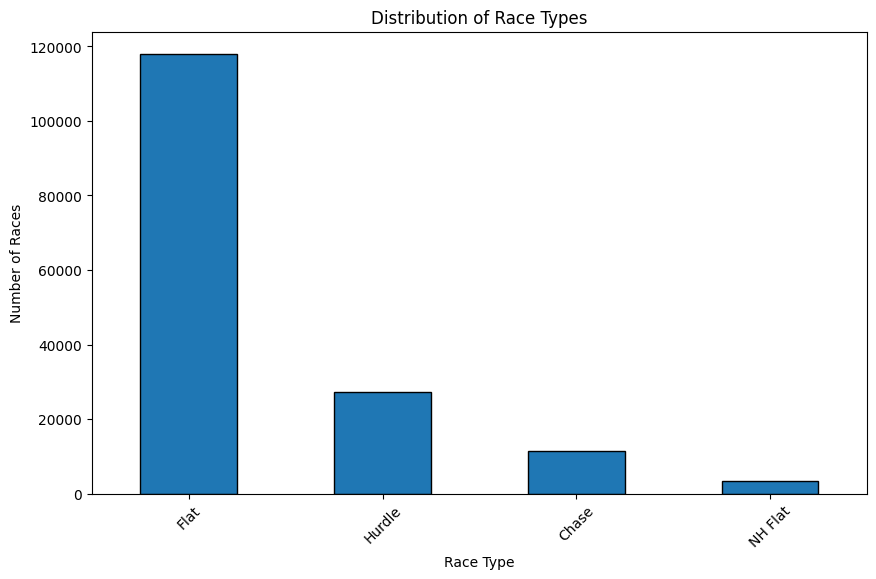

In [ ]:
# Count race types
race_type_counts = model_df['race_type'].value_counts()

# Create bar chart
plt.figure(figsize=(10,6))

race_type_counts.plot(
    kind='bar',
    edgecolor='black'
)

plt.xlabel('Race Type')
plt.ylabel('Number of Races')
plt.title('Distribution of Race Types')

plt.xticks(rotation=45)


This bar chart displays the distribution of different race types within the dataset, highlighting the prevalence of Flat races compared to other types like Hurdle, Chase, and NH Flat.

# Limit the Data to Flat Racing

In [ ]:
model_df = model_df[
    model_df['race_type'] == 'Flat'
]

In [ ]:
print(model_df['race_region'].value_counts())

race_region
GB     58637
FR     16601
IRE    15878
HK     10711
AUS     4273
USA     3213
UAE     2668
JPN     2127
GER      662
BHR      591
ARG      372
SAF      360
CAN      332
BRZ      314
ITY      248
NZ       246
CHI      208
JER      161
KSA      112
PER       80
QA        53
SWE       44
TUR       43
URU       24
KOR       24
SWI       20
HUN       12
POL       11
NOR        8
Name: count, dtype: int64


# Map of the full dataset

In [ ]:
import plotly.express as px

# Get unique regions
map_df = model_df[['race_region']].dropna().drop_duplicates()

# Convert racing region codes to ISO-3 country codes
country_map = {
    'GB': 'GBR',
    'IRE': 'IRL',
    'FR': 'FRA',
    'HK': 'HKG',
    'AUS': 'AUS',
    'USA': 'USA',
    'UAE': 'ARE',
    'JPN': 'JPN',
    'GER': 'DEU',
    'BHR': 'BHR',
    'ARG': 'ARG',
    'SAF': 'ZAF',
    'CAN': 'CAN',
    'BRZ': 'BRA',
    'ITY': 'ITA',
    'NZ': 'NZL',
    'CHI': 'CHL',
    'JER': 'JEY',
    'KSA': 'SAU',
    'PER': 'PER',
    'QA': 'QAT',
    'SWE': 'SWE',
    'TUR': 'TUR',
    'URU': 'URY',
    'KOR': 'KOR',
    'SWI': 'CHE',
    'HUN': 'HUN',
    'POL': 'POL',
    'CZE': 'CZE',
    'NOR': 'NOR'
}

# Apply mapping
map_df['iso_code'] = map_df['race_region'].map(country_map)

# Remove unmapped rows
map_df = map_df.dropna(subset=['iso_code'])

# Highlight countries
map_df['Included'] = 'Yes'

# Create map
fig = px.choropleth(
    map_df,
    locations='iso_code',
    color='Included',
    hover_name='race_region',
    title='Countries Included in Equi-Metrics Dataset'
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True)
)

fig.show()

The dataset contains races from a wide range of countries and racing environments. Great Britain contributed the largest proportion of races, followed by France, Ireland, Hong Kong, and Australia.
This international coverage is valuable because it introduces variation in:
*   track surfaces
*   race distance
*   training styles
*   horse development systems

The diversity of racing jurisdictions improves the robustness of future machine learning models and reduces overfitting to a single racing region.


# Convert to numeric Betting Odds Features

In [ ]:
model_df['runner_sp_dec'] = pd.to_numeric(
    model_df['runner_sp_dec'],
    errors='coerce'
)

model_df['runner_bsp'] = pd.to_numeric(
    model_df['runner_bsp'],
    errors='coerce'
)

In [ ]:
print(model_df[['runner_sp_dec', 'runner_bsp']].describe())

       runner_sp_dec     runner_bsp
count  118033.000000  118033.000000
mean       24.974768      33.858096
std        39.821056     115.451055
min         0.000000       0.000000
25%         6.000000       0.000000
50%        12.000000       5.900000
75%        26.000000      19.140000
max       566.000000    1000.000000


# Coverting Rating Columns to numeric

In [ ]:
rating_cols = [
    'runner_or',
    'runner_rpr',
    'runner_tsr'
]

for col in rating_cols:
    model_df[col] = pd.to_numeric(
        model_df[col],
        errors='coerce'
    )


In [ ]:
print(model_df[['runner_or', 'runner_rpr','runner_tsr']].describe())
model_df[['runner_or', 'runner_rpr','runner_tsr']].shape

          runner_or    runner_rpr    runner_tsr
count  78931.000000  95209.000000  86940.000000
mean      68.512156     63.790766     42.764274
std       17.234245     22.851283     20.958568
min       10.000000      1.000000      1.000000
25%       56.000000     49.000000     27.000000
50%       67.000000     64.000000     42.000000
75%       79.000000     79.000000     57.000000
max      157.000000    152.000000    125.000000


(118033, 3)

# Weight Columns

In [ ]:
model_df['runner_weight_lbs'] = pd.to_numeric(
    model_df['runner_weight_lbs'],
    errors='coerce'
)

In [ ]:
print(model_df[['runner_weight_lbs']].describe())

       runner_weight_lbs
count      118033.000000
mean          128.458143
std             6.421120
min           105.000000
25%           125.000000
50%           128.000000
75%           133.000000
max           177.000000


# Add a meter distance column for easier converstion

In [ ]:
# Ensure 'race_dist_y' is available in model_df
# It was not included in the initial model_df creation, so we retrieve it from the original df.
# The indices align since model_df is a filtered view of df.
if 'race_dist_y' not in model_df.columns and 'race_dist_y' in df.columns:
    model_df['race_dist_y'] = df.loc[model_df.index, 'race_dist_y']
elif 'race_dist_y' not in df.columns:
    print("Warning: 'race_dist_y' not found in the original 'df' DataFrame. Conversion may not be possible.")

# Convert yards to meters
model_df['race_dist_meters'] = (
    model_df['race_dist_y'] * 0.9144
)

# Preview
print(
    model_df[
        ['race_dist_y', 'race_dist_meters']
    ].head()
)

   race_dist_y  race_dist_meters
0         1320          1207.008
1         1320          1207.008
2         1320          1207.008
3         1320          1207.008
4         1320          1207.008


In [ ]:
model_df = model_df.drop(columns=['race_dist_y'])


In [ ]:
print(model_df.columns)

Index(['race_region', 'race_course', 'race_type', 'race_class', 'race_going',
       'race_surface', 'runner_age', 'runner_sex', 'runner_weight_lbs',
       'runner_draw', 'runner_headgear', 'runner_or', 'runner_rpr',
       'runner_tsr', 'runner_sp_dec', 'runner_bsp', 'runner_jockey',
       'runner_trainer', 'runner_position', 'race_dist_meters'],
      dtype='object')


# Gender Distribution

Gender Distribution

*   G - Gelding: castrated male horse often calmer temperment, most common

*   F - Filly: young female horse usually < 4 years old lower floor than male counterpart

*   M - Mare: adult female horse 4+ years old, lower floor than male counterpart
*   C - Colt; young male horse usually < 4 years old

*   H - Horse: adult male horse usually 4+ years old uncommon since many males become geldings

*   R - Rig: a partially castrated male horse or cryptochid super uncommon

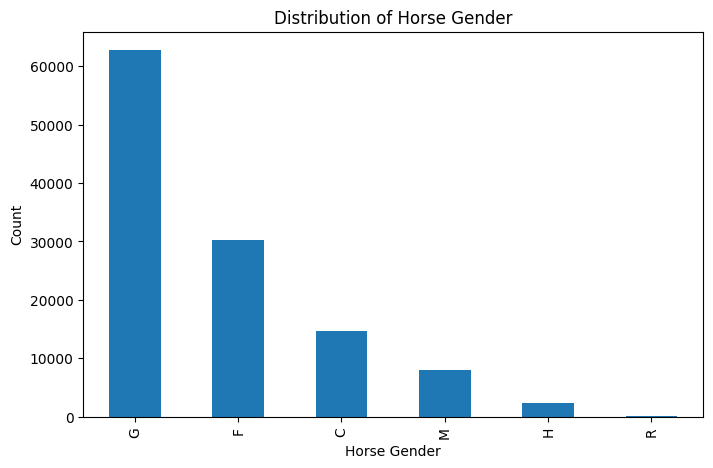

In [ ]:
# Count each gender category
gender_counts = model_df['runner_sex'].value_counts()

# Create chart
plt.figure(figsize=(8,5))

gender_counts.plot(kind='bar')

plt.xlabel('Horse Gender')
plt.ylabel('Count')
plt.title('Distribution of Horse Gender')

plt.show()

The analysis showed that geldings represented the majority of the dataset. This is expected because geldings are commonly used in racing due to their calmer temperament and longer racing careers.

Female horses accounted for a smaller percentage of the dataset because many successful fillies and mares are retired early for breeding purposes.

The imbalance between genders may influence predictive performance and should be considered during feature engineering.

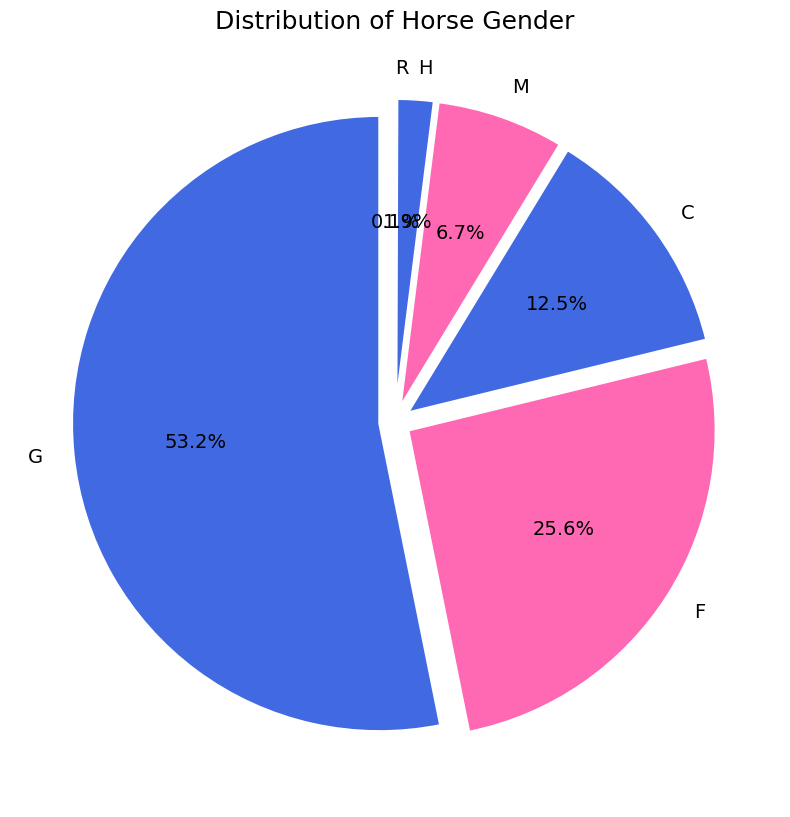

In [ ]:
# Count horse genders
gender_counts = model_df['runner_sex'].value_counts()

# Colors
colors = [
    'hotpink' if sex in ['F', 'M'] else 'royalblue'
    for sex in gender_counts.index
]

# Slightly separate slices
explode = [0.05] * len(gender_counts)

# Create pie chart
plt.figure(figsize=(10,10))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=explode,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 14}
)

plt.title(
    'Distribution of Horse Gender',
    fontsize=18
)

plt.show()

This pie chart illustrates the distribution of horse genders in the dataset, showing the proportion of Geldings, Fillies, Mares, Colts, and other categories.

# Histogram of horse ages

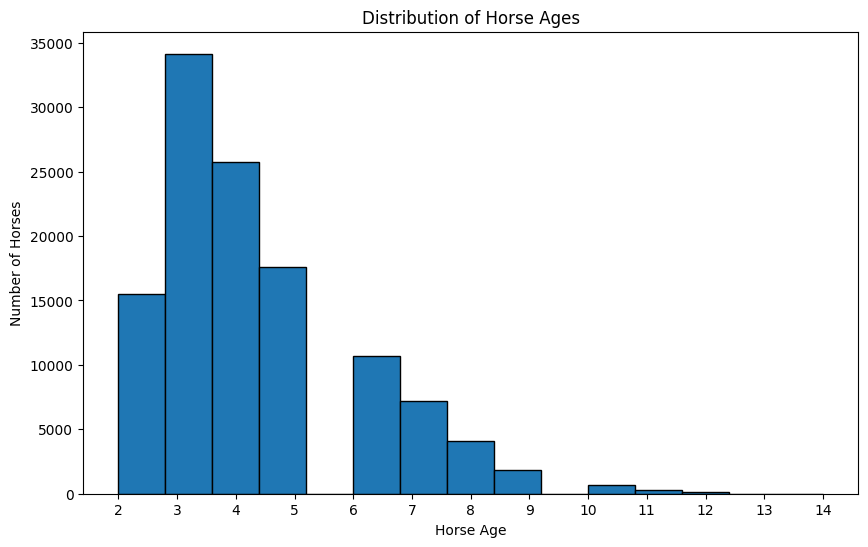

In [ ]:
# Create histogram
plt.figure(figsize=(10,6))

plt.hist(
    model_df['runner_age'].dropna(),
    bins=15,
    edgecolor='black'
)

plt.xlabel('Horse Age')
plt.ylabel('Number of Horses')
plt.title('Distribution of Horse Ages')

plt.xticks(range(
    int(model_df['runner_age'].min()),
    int(model_df['runner_age'].max()) + 1
))

plt.show()

This histogram shows the distribution of horse ages in the dataset, allowing us to see which age groups are most represented.

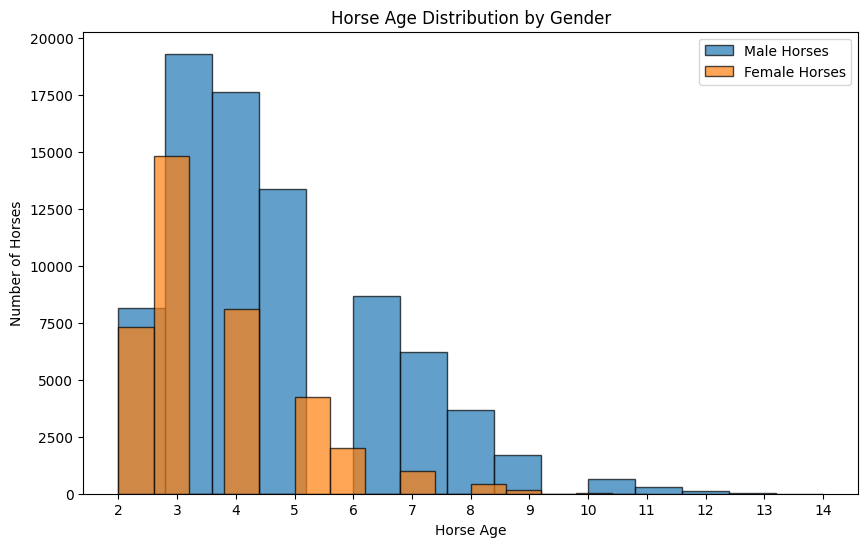

In [ ]:
# Separate ages by gender groups
female_ages = model_df[
    model_df['runner_sex'].isin(['F', 'M'])
]['runner_age']

male_ages = model_df[
    ~model_df['runner_sex'].isin(['F', 'M'])
]['runner_age']

# Create histogram
plt.figure(figsize=(10,6))

plt.hist(
    male_ages,
    bins=15,
    alpha=0.7,
    label='Male Horses',
    edgecolor='black'
)

plt.hist(
    female_ages,
    bins=15,
    alpha=0.7,
    label='Female Horses',
    edgecolor='black'
)

plt.xlabel('Horse Age')
plt.ylabel('Number of Horses')
plt.title('Horse Age Distribution by Gender')

plt.legend()

plt.xticks(range(
    int(model_df['runner_age'].min()),
    int(model_df['runner_age'].max()) + 1
))

plt.show()

*   flat peak around 4–5
*   jumps peak around 7–9


*   Very young horses → inexperienced
*   Middle-aged horses → peak performance

*   Older horses → decline (except jumps)

*   Female breeding usually 3-4 year olds
*   Male breeding often starts are 4-6 years old where elite race horses retired early if very succesful









# Histogram of Race distances in Meters

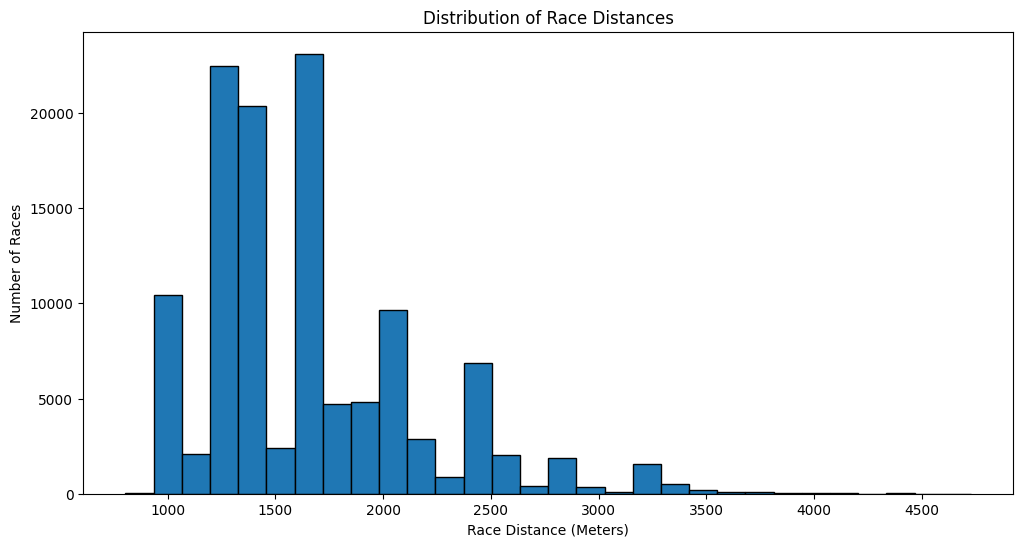

In [ ]:

# Create histogram of race distances in meters
plt.figure(figsize=(12,6))

plt.hist(
    model_df['race_dist_meters'].dropna(),
    bins=30,
    edgecolor='black'
)

plt.xlabel('Race Distance (Meters)')
plt.ylabel('Number of Races')
plt.title('Distribution of Race Distances')

plt.show()

This histogram illustrates the distribution of race distances in meters, providing an overview of the most common race lengths.

Distance categories

*   Sprint < 1600m
*   Mile >= 1600m & < 1800m
*   Medium >= 1800m & <= 2400m
*   Long > 2400m



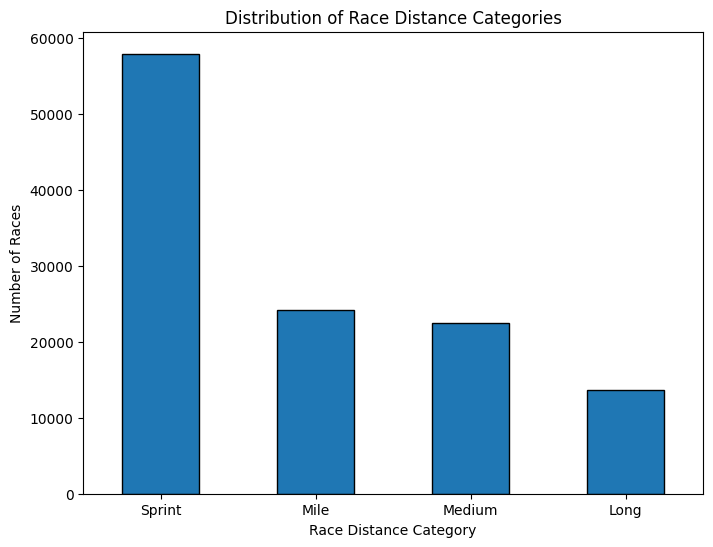

In [ ]:
# Create distance categories
conditions = [
    model_df['race_dist_meters'] < 1600,

    (model_df['race_dist_meters'] >= 1600) &
    (model_df['race_dist_meters'] < 1800),

    (model_df['race_dist_meters'] >= 1800) &
    (model_df['race_dist_meters'] <= 2400),

    model_df['race_dist_meters'] > 2400
]

categories = [
    'Sprint',
    'Mile',
    'Medium',
    'Long'
]

model_df['distance_category'] = pd.cut(
    model_df['race_dist_meters'],
    bins=[0, 1600, 1800, 2400, float('inf')],
    labels=categories
)

# Count categories
distance_counts = model_df['distance_category'].value_counts()

# Plot
plt.figure(figsize=(8,6))

distance_counts.plot(
    kind='bar',
    edgecolor='black'
)

plt.xlabel('Race Distance Category')
plt.ylabel('Number of Races')
plt.title('Distribution of Race Distance Categories')

plt.xticks(rotation=0)

plt.show()

Race distances were converted from yards into meters to standardize analysis across racing jurisdictions.
Distances were categorized into four groups:
*   Sprint: under 1600 meters
*   Mile: 1600–1799 meters
*   Medium: 1800–2400 meters
*   Long: over 2400 meters


Sprint races represented the largest category within the dataset. This is likely because sprint races:


*   Require less endurance conditioning
*   Are more accessible for younger horses
*   Are more popular with casual viewers
*   Occur more frequently across racing calendars


Distance category is expected to play a major role in prediction accuracy because different horses specialize in different race lengths.

# Race Classes

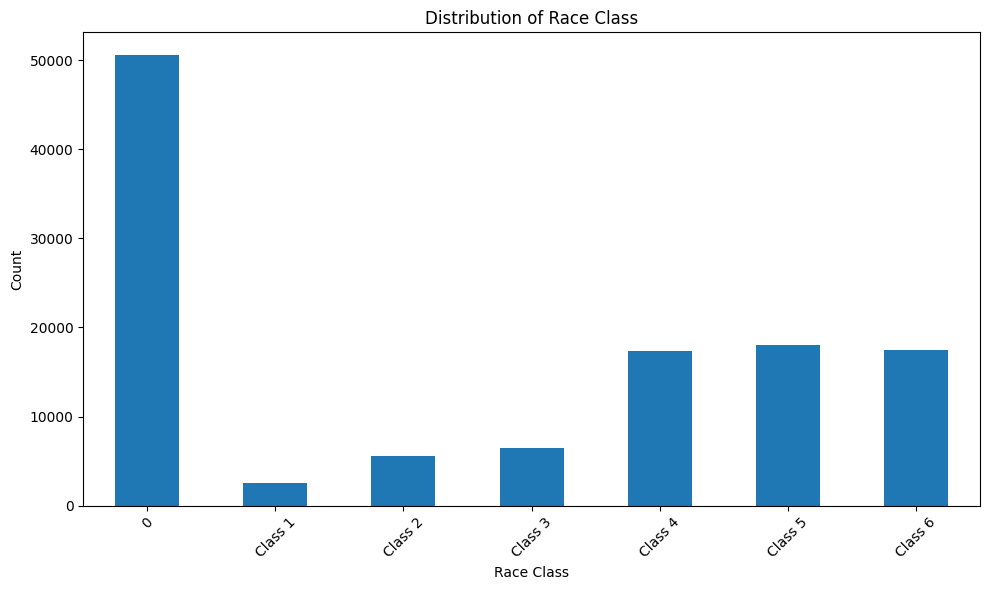

In [ ]:
# Convert race_class to string to avoid comparison errors between int and str
race_class_counts = model_df["race_class"].astype(str).value_counts().sort_index()

plt.figure(figsize=(10, 6))
race_class_counts.plot(kind="bar")

plt.title("Distribution of Race Class")
plt.xlabel("Race Class")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Race class is one of the strongest predictive features because it reflects


*   competition quality
*   horse ability
*   trainer intent
*   earnings level
*   Pace Quality

In terms of class rank, lower is more prestigious while 0 is a catch all below class 6.


*   A horse may qualify for a higher class race by complete a race 1 class below
*   A horse that participates in class 1,2,3 are also considered in the professional level and those respective classes are called graded races and are internationally reconginzed races.





# Race Surfaces

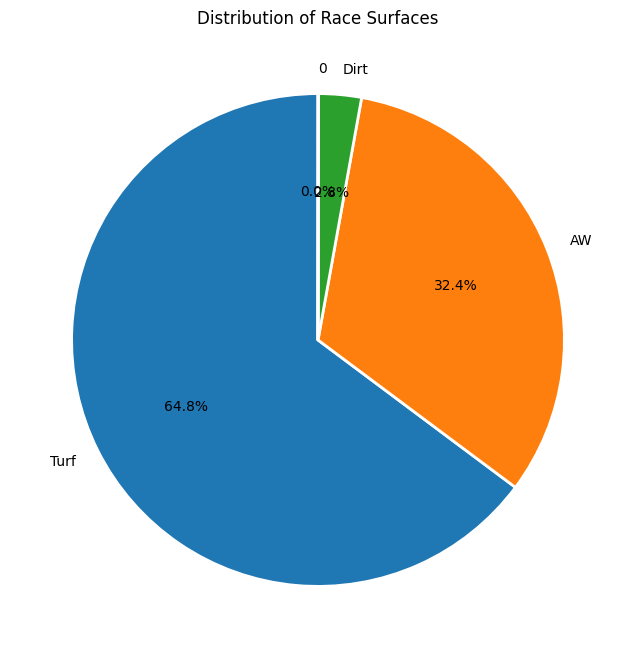

In [ ]:
# Count surface types
surface_counts = model_df['race_surface'].value_counts()

# Create pie chart
plt.figure(figsize=(8,8))

plt.pie(
    surface_counts,
    labels=surface_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title('Distribution of Race Surfaces')

plt.show()

Surfaces
*   Turf: grass softer stamina/tactical
*   Dirt: Faster pace/speed focus
*   All Weather (AW):  consistent syntthetic surface

some horses can


*   perform much better on turf (European Countries)
*   struggle on dirt (USA is almost exclusively dirt)
*   specialize on AW (Middle East & Asia historically)






# Odds Distribution

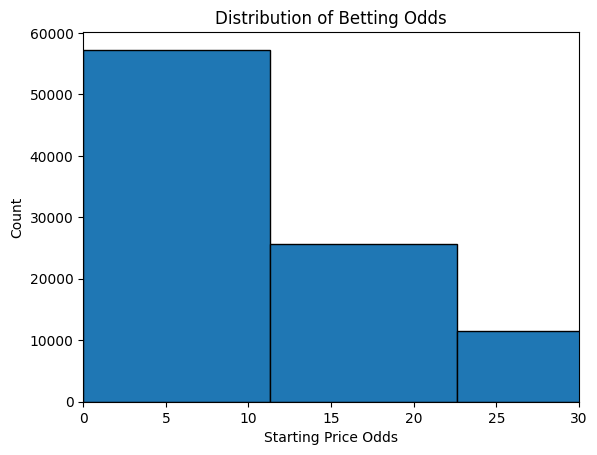

In [ ]:
plt.hist(
    model_df['runner_sp_dec'],
    bins=50,
    edgecolor='black'
)

plt.xlim(0, 30)

plt.xlabel('Starting Price Odds')
plt.ylabel('Count')
plt.title('Distribution of Betting Odds')

plt.show()

The distribution of starting price (SP) odds shows a right-skewed pattern, with most horses having relatively low odds (favorites) and a long tail extending to high odds (longshots). The x-axis is limited to 30 to better visualize the bulk of the data, as odds can go much higher. This indicates that most horses are not considered extreme longshots, but a significant number of races still feature horses with higher odds.

# Odds Distribution: Winners vs Losers

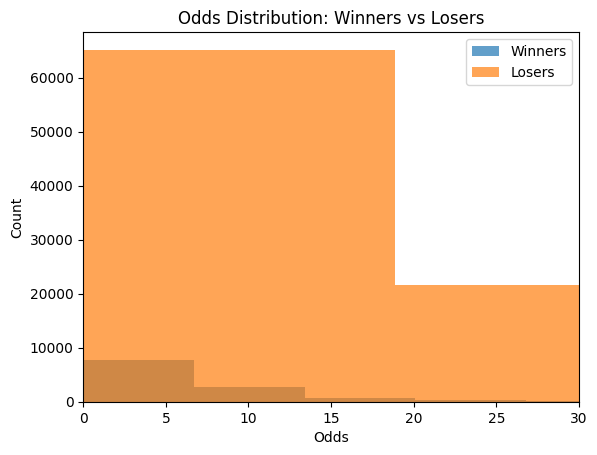

In [ ]:
model_df['winner'] = (model_df['runner_position'] == 1).astype(int)

winners = model_df[
    model_df['winner'] == 1
]['runner_sp_dec']

losers = model_df[
    model_df['winner'] == 0
]['runner_sp_dec']

plt.hist(winners, bins=30, alpha=0.7, label='Winners')
plt.hist(losers, bins=30, alpha=0.7, label='Losers')

plt.xlim(0, 30)

plt.legend()

plt.xlabel('Odds')
plt.ylabel('Count')
plt.title('Odds Distribution: Winners vs Losers')

plt.show()

Starting Price (SP) odds and Betfair Starting Price (BSP) odds were analyzed numerically.
The betting distribution showed:
*   Most horses entered races with relatively short odds
*   A smaller number of horses had extremely high odds
*   Odds distributions were strongly right-skewed

When comparing winners versus non-winners:
*   Winning horses generally had lower betting odds
*   Favorites won more frequently than longshots
*   However, upsets still occurred regularly

This indicates that betting markets already contain substantial predictive information, making odds-based features potentially very powerful in machine learning models.

# Surface by Distance Category

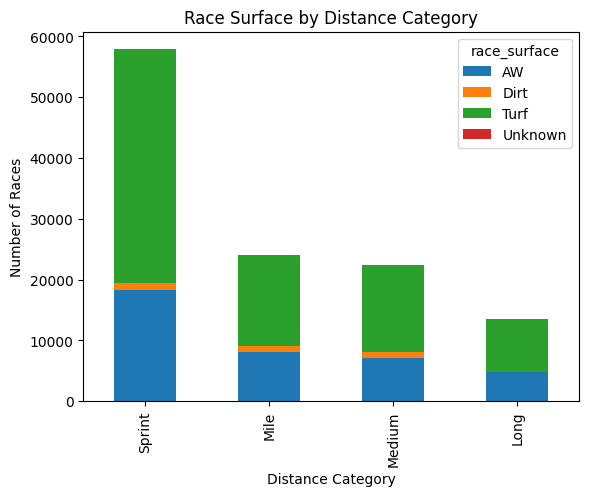

In [ ]:
model_df['race_surface'] = model_df['race_surface'].replace(0, 'Unknown')

surface_distance = pd.crosstab(
    model_df['distance_category'],
    model_df['race_surface']
)

surface_distance.plot(kind='bar', stacked=True)

plt.xlabel('Distance Category')
plt.ylabel('Number of Races')
plt.title('Race Surface by Distance Category')

plt.show()

This stacked bar chart visualizes the distribution of race surfaces across different distance categories, showing how surface types vary with race length.

# Feature Correlation Heatmap

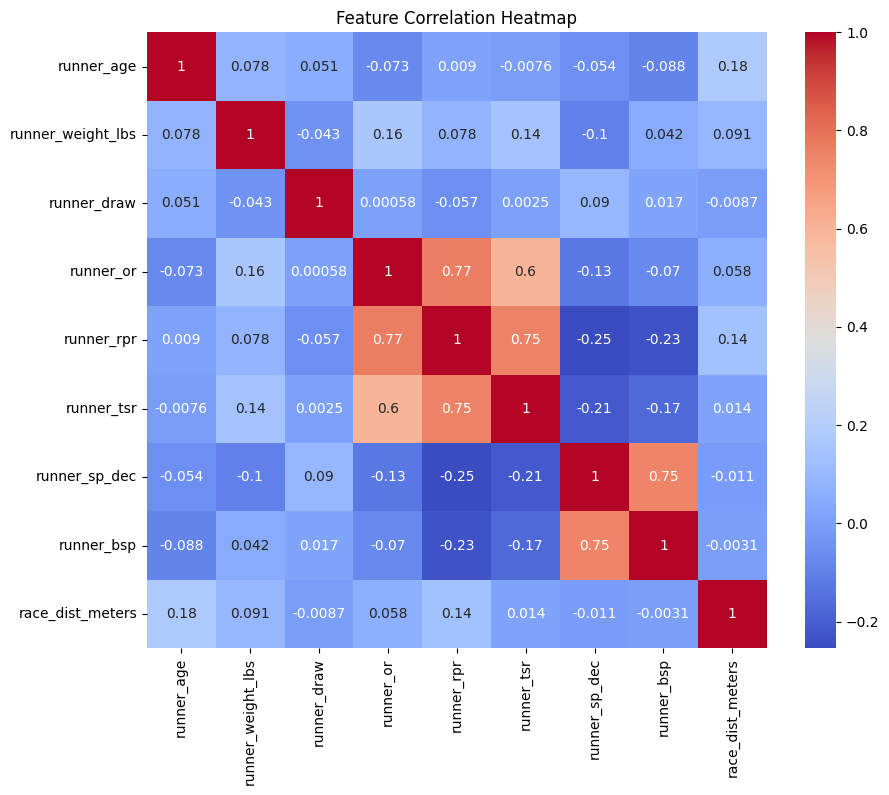

In [ ]:
numeric_cols = [
    'runner_age',
    'runner_weight_lbs',
    'runner_draw',
    'runner_or',
    'runner_rpr',
    'runner_tsr',
    'runner_sp_dec',
    'runner_bsp',
    'race_dist_meters'
]

corr = model_df[numeric_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Feature Correlation Heatmap')

plt.show()

This heatmap shows the correlation between numeric features. We can observe strong relationships between different rating types (OR, RPR, TSR) and betting odds, which helps identify which features provide unique vs. redundant information for the model.

# Official Rating vs Winning Boxplot

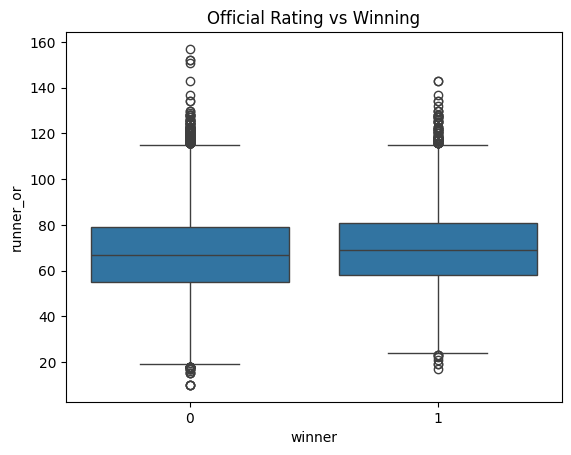

In [ ]:
sns.boxplot(
    x='winner',
    y='runner_or',
    data=model_df
)

plt.title('Official Rating vs Winning')

plt.show()

The 'Official Rating vs Winning' boxplot shows that winners tend to have a slightly higher and more consistent Official Rating compared to non-winners, though there is significant overlap between the two groups.

winners have


*   slightly higher official rating
*   tighter clustering around stronger values

Official Rating has predictive value but


*   many lower-rated horses still win
*   OR alone isn't enough





# RPR vs Winning Boxplot

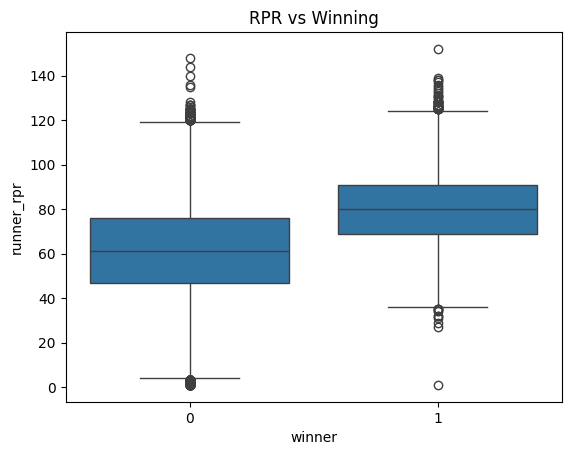

In [ ]:
# RPR vs Winning
sns.boxplot(
    x='winner',
    y='runner_rpr',
    data=model_df
)

plt.title('RPR vs Winning')

plt.show()

The 'RPR vs Winning' boxplot indicates that Racing Post Ratings (RPR) are a strong separator, with winners showing a notably higher median RPR than non-winners.

Winners have:


*   higher RPR values

*   much higher median
*   stronger overall distribution

RPR appears to be:
*   a stronger predictor than OR
*   associated with winning propbability
*   RPR reflects recent race performance more dynamically





# TSR vs Winning Boxplot

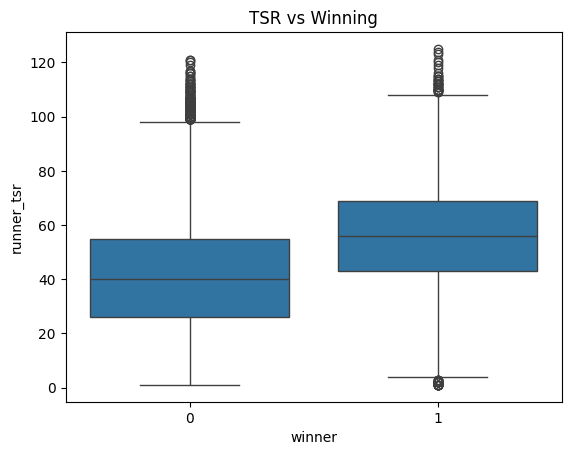

In [ ]:
sns.boxplot(
    x='winner',
    y='runner_tsr',
    data=model_df
)

plt.title('TSR vs Winning')

plt.show()

Similar to RPR, the 'TSR vs Winning' plot demonstrates that Top Speed Ratings (TSR) provide a clear signal, with winning horses generally possessing higher speed figures.

Winning horses tend to have:

*   significantly highter TSR
*   higher median speed ratings

*   better upper quartiles
TSR is strongly correlated with winning suggests:


*   speed performance is critical in flat racing
*   recent pace/speed matters heavily






# Feature Engineering

# Focus solely on pedigree

In [ ]:
pd.set_option('future.no_silent_downcasting', True)

df = pd.read_csv("/content/drive/MyDrive/EquiMetrics/raw_data/racingapidata.csv")

df["race_date"] = pd.to_datetime(df["race_date"], errors="coerce")
df = df.sort_values("race_date").reset_index(drop=True)

df["winner"] = (pd.to_numeric(df["runner_position"], errors="coerce") == 1).astype(int)

df["runner_rpr"] = pd.to_numeric(df["runner_rpr"], errors="coerce")
df["runner_tsr"] = pd.to_numeric(df["runner_tsr"], errors="coerce")

# Historical Sires (Father) Features

In [ ]:
if "winner" not in df.columns:
    df["winner"] = (pd.to_numeric(df["runner_position"], errors="coerce") == 1).astype(int)

df["sire_starts_before" ] = df.groupby("runner_sire_id").cumcount()

df["sire_wins_before"] = (
    df.groupby("runner_sire_id")["winner"]
      .cumsum()
      .groupby(df["runner_sire_id"])
      .shift(1)
)
df["sire_sample_size"] = df["sire_starts_before"]

df["sire_win_rate"] = df["sire_wins_before"] / df["sire_starts_before"]

df["sire_avg_rpr"] = (
    df.groupby("runner_sire_id")["runner_rpr"]
      .transform(lambda x: x.expanding().mean().shift(1))
)

df["sire_avg_tsr"] = (
    df.groupby("runner_sire_id")["runner_tsr"]
      .transform(lambda x: x.expanding().mean().shift(1))
)

# Historical Damsire (Maternal Grandfather) Features

In [ ]:
df["damsire_starts_before"] = df.groupby("runner_damsire_id").cumcount()

df["damsire_wins_before"] = (
    df.groupby("runner_damsire_id")["winner"]
      .cumsum()
      .groupby(df["runner_damsire_id"])
      .shift(1)
)

df["damsire_sample_size"] = df["damsire_starts_before"]

df["damsire_win_rate"] = df["damsire_wins_before"] / df["damsire_starts_before"]

df["damsire_avg_rpr"] = (
    df.groupby("runner_damsire_id")["runner_rpr"]
      .transform(lambda x: x.expanding().mean().shift(1))
)

df["damsire_avg_tsr"] = (
    df.groupby("runner_damsire_id")["runner_tsr"]
      .transform(lambda x: x.expanding().mean().shift(1))
)

# Dam/Broodmare (Mother) Features

In [ ]:
df["dam_starts_before"] = df.groupby("runner_dam_id").cumcount()

df["dam_wins_before"] = (
    df.groupby("runner_dam_id")["winner"]
      .cumsum()
      .groupby(df["runner_dam_id"])
      .shift(1)
)

df["dam_sample_size"] = df["dam_starts_before"]

df["dam_win_rate"] = df["dam_wins_before"] / df["dam_starts_before"]

df["dam_avg_rpr"] = (
    df.groupby("runner_dam_id")["runner_rpr"]
      .transform(lambda x: x.expanding().mean().shift(1))
)

df["dam_avg_tsr"] = (
    df.groupby("runner_dam_id")["runner_tsr"]
      .transform(lambda x: x.expanding().mean().shift(1))
)

# Simple Pedigree Score

In [ ]:
pedigree_cols = [
    "sire_win_rate",
    "sire_avg_rpr",
    "sire_avg_tsr",
    "damsire_win_rate",
    "damsire_avg_rpr",
    "damsire_avg_tsr",
    "dam_win_rate",
    "dam_avg_rpr",
    "dam_avg_tsr"
]

df[pedigree_cols] = df[pedigree_cols].fillna(0).infer_objects(copy=False)

df["pedigree_score"] = (
    df["sire_win_rate"] * 0.22 +
    df["sire_avg_rpr"] * 0.18 +
    df["sire_avg_tsr"] * 0.12 +

    df["damsire_win_rate"] * 0.15 +
    df["damsire_avg_rpr"] * 0.10 +
    df["damsire_avg_tsr"] * 0.08 +

    df["dam_win_rate"] * 0.08 +
    df["dam_avg_rpr"] * 0.05 +
    df["dam_avg_tsr"] * 0.02
)

The math only suggests Sire > Damsire > Dam in thouroghbred flat horseracing

# Check columns

In [ ]:
df[pedigree_cols].head()

,sire_win_rate,sire_avg_rpr,sire_avg_tsr,damsire_win_rate,damsire_avg_rpr,damsire_avg_tsr,dam_win_rate,dam_avg_rpr,dam_avg_tsr
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df[pedigree_cols].isnull().sum()

,0
sire_win_rate,0
sire_avg_rpr,0
sire_avg_tsr,0
damsire_win_rate,0
damsire_avg_rpr,0
damsire_avg_tsr,0
dam_win_rate,0
dam_avg_rpr,0
dam_avg_tsr,0


# Pedigree Column Graphs

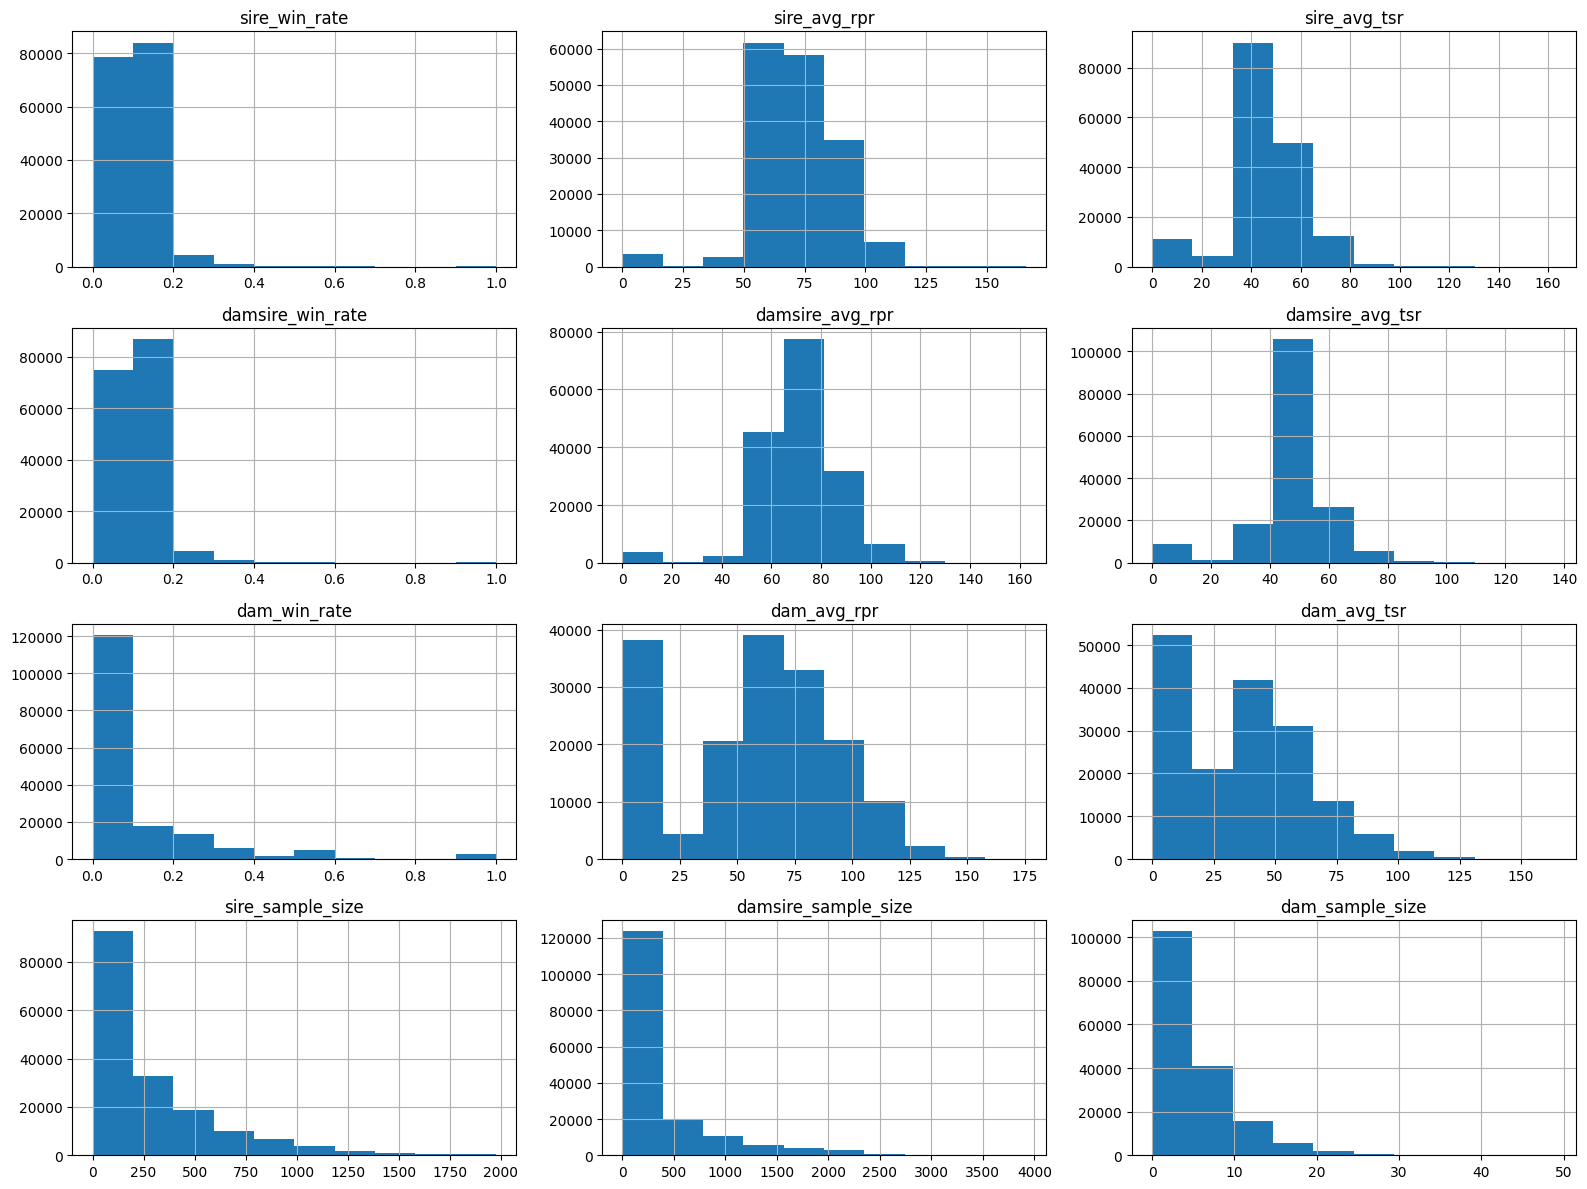

In [ ]:

pedigree_cols = [
    "sire_win_rate",
    "sire_avg_rpr",
    "sire_avg_tsr",

    "damsire_win_rate",
    "damsire_avg_rpr",
    "damsire_avg_tsr",

    "dam_win_rate",
    "dam_avg_rpr",
    "dam_avg_tsr",

    "sire_sample_size",
    "damsire_sample_size",
    "dam_sample_size",
]

df[pedigree_cols].hist(figsize=(16, 12))

plt.tight_layout()
plt.show()

These histograms display the distributions of various pedigree-related features, such as sire win rate, average RPR, and sample sizes for sire, damsire, and dam. They provide insights into the spread and characteristics of these engineered features.

# Pedigree Score Graph

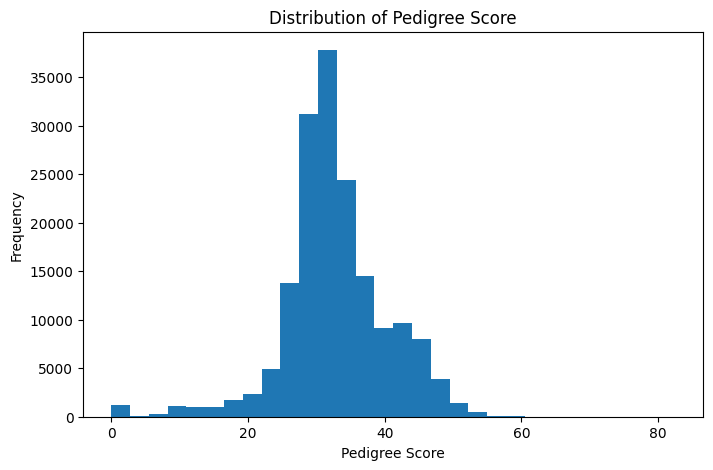

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["pedigree_score"], bins=30)

plt.title("Distribution of Pedigree Score")
plt.xlabel("Pedigree Score")
plt.ylabel("Frequency")

plt.show()

This histogram shows the distribution of the calculated pedigree score, indicating the spread of pedigree strength among horses in the dataset.

In [ ]:
df["pedigree_score"].describe()

,pedigree_score
count,168407.000000
mean,32.701393
std,7.642827
min,0.000000
25%,28.967724
50%,31.967289
75%,36.531058
max,82.470000


# Pedigree Score vs Winning

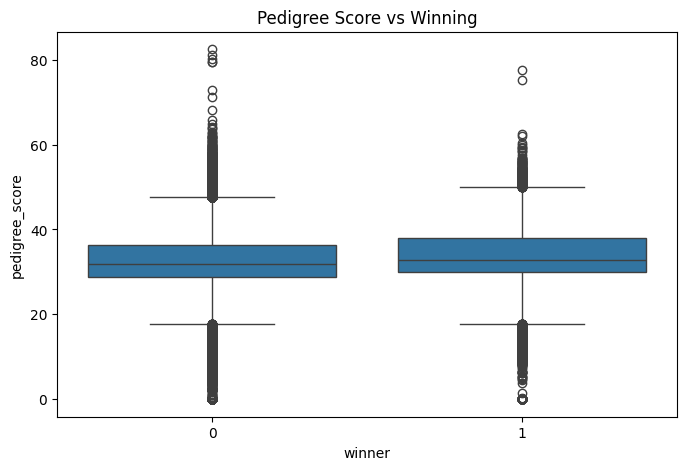

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="winner",
    y="pedigree_score",
    data=df
)

plt.title("Pedigree Score vs Winning")

plt.show()

This boxplot compares the pedigree score of winning horses versus non-winning horses, indicating if there's a noticeable difference in pedigree scores between these groups.

In [ ]:
print("Columns in original df:")
print(df[["runner_horse", "race_date"]].head())

print("\nColumns available in model_df:")
print(model_df.columns.tolist())

print("\nFirst 5 rows of model_df:")
print(model_df.head())

Columns in original df:
        runner_horse  race_date
0    Two Sharp (USA) 2025-05-26
1         Pasha (GB) 2025-05-26
2      Mandana (IRE) 2025-05-26
3  Two B Tanned (GB) 2025-05-26
4      Dartman (IRE) 2025-05-26

Columns available in model_df:
['race_region', 'race_course', 'race_type', 'race_class', 'race_going', 'race_surface', 'runner_age', 'runner_sex', 'runner_weight_lbs', 'runner_draw', 'runner_headgear', 'runner_or', 'runner_rpr', 'runner_tsr', 'runner_sp_dec', 'runner_bsp', 'runner_jockey', 'runner_trainer', 'runner_position', 'race_dist_meters', 'distance_category', 'winner']

First 5 rows of model_df:
  race_region            race_course race_type race_class race_going  \
0         USA  Churchill Downs (USA)      Flat          0       Fast   
1         USA  Churchill Downs (USA)      Flat          0       Fast   
2         USA  Churchill Downs (USA)      Flat          0       Fast   
3         USA  Churchill Downs (USA)      Flat          0       Fast   
4         USA  Ch

# Merge the two dataframes

In [ ]:
merge_cols = [
    "race_race_id",
    "runner_horse_id"
]

In [ ]:
pedigree_cols = [
    "sire_win_rate",
    "sire_avg_rpr",
    "sire_avg_tsr",
    "sire_sample_size",

    "damsire_win_rate",
    "damsire_avg_rpr",
    "damsire_avg_tsr",
    "damsire_sample_size",

    "dam_win_rate",
    "dam_avg_rpr",
    "dam_avg_tsr",
    "dam_sample_size",
    "pedigree_score"
]

# Ensure ID columns are in model_df before merging
for col in merge_cols:
    if col not in model_df.columns:
        model_df[col] = df.loc[model_df.index, col]

model_df = model_df.merge(
    df[merge_cols + pedigree_cols],
    on=merge_cols,
    how="left"
)

print(f"New model_df shape: {model_df.shape}")
print("Pedigree features successfully merged.")

New model_df shape: (118033, 37)
Pedigree features successfully merged.


In [ ]:
# Verify the merge and check for nulls in the new features
pedigree_summary = model_df[pedigree_cols].isnull().sum()
print("Null counts in merged pedigree columns:")
print(pedigree_summary)

# Fill any NaN values from the merge with 0 (for cases where no pedigree data was found)
model_df[pedigree_cols] = model_df[pedigree_cols].fillna(0)

print("\nUpdated model_df preview (first 5 rows):")
display(model_df.head())

Null counts in merged pedigree columns:
sire_win_rate          0
sire_avg_rpr           0
sire_avg_tsr           0
sire_sample_size       0
damsire_win_rate       0
damsire_avg_rpr        0
damsire_avg_tsr        0
damsire_sample_size    5
dam_win_rate           0
dam_avg_rpr            0
dam_avg_tsr            0
dam_sample_size        3
pedigree_score         0
dtype: int64

Updated model_df preview (first 5 rows):


,race_region,race_course,race_type,race_class,race_going,race_surface,runner_age,runner_sex,runner_weight_lbs,runner_draw,...,sire_sample_size,damsire_win_rate,damsire_avg_rpr,damsire_avg_tsr,damsire_sample_size,dam_win_rate,dam_avg_rpr,dam_avg_tsr,dam_sample_size,pedigree_score
0,USA,Churchill Downs (USA),Flat,0,Fast,Dirt,4,F,118,7.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,USA,Churchill Downs (USA),Flat,0,Fast,Dirt,4,F,118,3.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,USA,Churchill Downs (USA),Flat,0,Fast,Dirt,4,F,118,5.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,USA,Churchill Downs (USA),Flat,0,Fast,Dirt,4,F,118,1.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,USA,Churchill Downs (USA),Flat,0,Fast,Dirt,4,F,118,6.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
model_df.columns

Index(['race_region', 'race_course', 'race_type', 'race_class', 'race_going',
       'race_surface', 'runner_age', 'runner_sex', 'runner_weight_lbs',
       'runner_draw', 'runner_headgear', 'runner_or', 'runner_rpr',
       'runner_tsr', 'runner_sp_dec', 'runner_bsp', 'runner_jockey',
       'runner_trainer', 'runner_position', 'race_dist_meters',
       'distance_category', 'winner', 'race_race_id', 'runner_horse_id',
       'sire_win_rate', 'sire_avg_rpr', 'sire_avg_tsr', 'sire_sample_size',
       'damsire_win_rate', 'damsire_avg_rpr', 'damsire_avg_tsr',
       'damsire_sample_size', 'dam_win_rate', 'dam_avg_rpr', 'dam_avg_tsr',
       'dam_sample_size', 'pedigree_score'],
      dtype='object')

# Horse ID lookup

In [ ]:
horse_lookup = (
    df[["runner_horse_id", "runner_horse"]]
    .drop_duplicates()
)

model_df = model_df.merge(
    horse_lookup,
    on="runner_horse_id",
    how="left"
)

In [ ]:
model_df[["runner_horse_id", "runner_horse"]].head()

,runner_horse_id,runner_horse
0,hrs_44873871,Two Sharp (USA)
1,hrs_37096640,Pasha (GB)
2,hrs_43131613,Mandana (IRE)
3,hrs_39372354,Two B Tanned (GB)
4,hrs_31117821,Dartman (IRE)


In [ ]:
model_df.columns

Index(['race_region', 'race_course', 'race_type', 'race_class', 'race_going',
       'race_surface', 'runner_age', 'runner_sex', 'runner_weight_lbs',
       'runner_draw', 'runner_headgear', 'runner_or', 'runner_rpr',
       'runner_tsr', 'runner_sp_dec', 'runner_bsp', 'runner_jockey',
       'runner_trainer', 'runner_position', 'race_dist_meters',
       'distance_category', 'winner', 'race_race_id', 'runner_horse_id',
       'sire_win_rate', 'sire_avg_rpr', 'sire_avg_tsr', 'sire_sample_size',
       'damsire_win_rate', 'damsire_avg_rpr', 'damsire_avg_tsr',
       'damsire_sample_size', 'dam_win_rate', 'dam_avg_rpr', 'dam_avg_tsr',
       'dam_sample_size', 'pedigree_score', 'runner_horse'],
      dtype='object')

In [ ]:
horse_col = model_df.pop("runner_horse")
model_df.insert(0, "runner_horse", horse_col)

# Move horse names to first column

In [ ]:
model_df.columns

Index(['runner_horse', 'race_region', 'race_course', 'race_type', 'race_class',
       'race_going', 'race_surface', 'runner_age', 'runner_sex',
       'runner_weight_lbs', 'runner_draw', 'runner_headgear', 'runner_or',
       'runner_rpr', 'runner_tsr', 'runner_sp_dec', 'runner_bsp',
       'runner_jockey', 'runner_trainer', 'runner_position',
       'race_dist_meters', 'distance_category', 'winner', 'race_race_id',
       'runner_horse_id', 'sire_win_rate', 'sire_avg_rpr', 'sire_avg_tsr',
       'sire_sample_size', 'damsire_win_rate', 'damsire_avg_rpr',
       'damsire_avg_tsr', 'damsire_sample_size', 'dam_win_rate', 'dam_avg_rpr',
       'dam_avg_tsr', 'dam_sample_size', 'pedigree_score'],
      dtype='object')

In [ ]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118126 entries, 0 to 118125
Data columns (total 38 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   runner_horse         118126 non-null  object  
 1   race_region          118126 non-null  object  
 2   race_course          118126 non-null  object  
 3   race_type            118126 non-null  object  
 4   race_class           118126 non-null  object  
 5   race_going           118126 non-null  object  
 6   race_surface         118126 non-null  object  
 7   runner_age           118126 non-null  int64   
 8   runner_sex           118126 non-null  object  
 9   runner_weight_lbs    118126 non-null  int64   
 10  runner_draw          118126 non-null  float64 
 11  runner_headgear      118126 non-null  object  
 12  runner_or            79000 non-null   float64 
 13  runner_rpr           95284 non-null   float64 
 14  runner_tsr           87008 non-null   float64 
 15  

In [ ]:
model_df.columns

Index(['runner_horse', 'race_region', 'race_course', 'race_type', 'race_class',
       'race_going', 'race_surface', 'runner_age', 'runner_sex',
       'runner_weight_lbs', 'runner_draw', 'runner_headgear', 'runner_or',
       'runner_rpr', 'runner_tsr', 'runner_sp_dec', 'runner_bsp',
       'runner_jockey', 'runner_trainer', 'runner_position',
       'race_dist_meters', 'distance_category', 'winner', 'race_race_id',
       'runner_horse_id', 'sire_win_rate', 'sire_avg_rpr', 'sire_avg_tsr',
       'sire_sample_size', 'damsire_win_rate', 'damsire_avg_rpr',
       'damsire_avg_tsr', 'damsire_sample_size', 'dam_win_rate', 'dam_avg_rpr',
       'dam_avg_tsr', 'dam_sample_size', 'pedigree_score'],
      dtype='object')

# Feature Engineering Elo

In [ ]:
# Add race_date if model_df does not already have it
if "race_date" not in model_df.columns:
    model_df = model_df.merge(
        df[["race_race_id", "runner_horse_id", "race_date"]],
        on=["race_race_id", "runner_horse_id"],
        how="left"
    )

model_df["race_date"] = pd.to_datetime(model_df["race_date"])

# Sort chronologically to avoid data leakage
model_df = model_df.sort_values(["race_date", "race_race_id"]).copy()

elo_ratings = {}
initial_elo = 1500
k = 20

model_df["horse_elo_before"] = np.nan

for race_id, race in model_df.groupby("race_race_id", sort=False):
    horses = race["runner_horse_id"].tolist()
    positions = race["runner_position"].tolist()

    # Elo before this race
    for idx, horse_id in zip(race.index, horses):
        model_df.loc[idx, "horse_elo_before"] = elo_ratings.get(horse_id, initial_elo)

    updates = {horse_id: 0 for horse_id in horses}

    # Pairwise matchups inside each race
    for i in range(len(horses)):
        for j in range(i + 1, len(horses)):
            horse_a = horses[i]
            horse_b = horses[j]

            pos_a = positions[i]
            pos_b = positions[j]

            rating_a = elo_ratings.get(horse_a, initial_elo)
            rating_b = elo_ratings.get(horse_b, initial_elo)

            expected_a = 1 / (1 + 10 ** ((rating_b - rating_a) / 400))
            expected_b = 1 - expected_a

            if pos_a < pos_b:
                score_a = 1
                score_b = 0
            elif pos_a > pos_b:
                score_a = 0
                score_b = 1
            else:
                score_a = 0.5
                score_b = 0.5

            updates[horse_a] += k * (score_a - expected_a)
            updates[horse_b] += k * (score_b - expected_b)

    # Apply updates after the race
    for horse_id in horses:
        elo_ratings[horse_id] = elo_ratings.get(horse_id, initial_elo) + updates[horse_id]

# Race relative elo

In [ ]:
model_df["horse_elo_rank"] = (
    model_df.groupby("race_race_id")["horse_elo_before"]
    .rank(ascending=False, method="dense")
)

model_df["horse_elo_vs_race_avg"] = (
    model_df["horse_elo_before"] -
    model_df.groupby("race_race_id")["horse_elo_before"].transform("mean")
)

In [ ]:
elo_cols = [
    "horse_elo_before",
    "horse_elo_rank",
    "horse_elo_vs_race_avg"
]


In [ ]:
selected_features = selected_features + elo_cols

In [ ]:
model_df[[
    "runner_horse",
    "race_date",
    "race_race_id",
    "runner_position",
    "horse_elo_before",
    "horse_elo_rank",
    "horse_elo_vs_race_avg"
]].tail(20)

,runner_horse,race_date,race_race_id,runner_position,horse_elo_before,horse_elo_rank,horse_elo_vs_race_avg
118064,Mon Paulin (FR),2026-05-26,rac_11981021,1,1377.460399,6.0,-113.582242
118065,Kasymir (FR),2026-05-26,rac_11981021,2,1531.429262,2.0,40.386621
118066,Meris Chop (FR),2026-05-26,rac_11981021,3,1500.000000,4.0,8.957359
118067,Patchouly (FR),2026-05-26,rac_11981021,4,1500.000000,4.0,8.957359
118068,Mr Somebody (FR),2026-05-26,rac_11981021,1,1578.854218,1.0,87.811577
118069,Invincible Guard (FR),2026-05-26,rac_11981021,2,1500.000000,4.0,8.957359
118074,Art De Rue (GB),2026-05-26,rac_11981021,7,1500.000000,4.0,8.957359
118077,Coton Star (FR),2026-05-26,rac_11981021,1,1500.000000,4.0,8.957359
118078,Anolante (FR),2026-05-26,rac_11981021,2,1387.709263,5.0,-103.333378
118080,Purple Power (FR),2026-05-26,rac_11981021,4,1500.000000,4.0,8.957359


In [ ]:
model_df[[
    "runner_horse",
    "race_date",
    "race_race_id",
    "runner_position",
    "horse_elo_before",
    "horse_elo_rank",
    "horse_elo_vs_race_avg"
]].describe()

,race_date,runner_position,horse_elo_before,horse_elo_rank,horse_elo_vs_race_avg
count,118126,118126.000000,118126.000000,118126.000000,1.181260e+05
mean,2025-11-13 09:14:04.609992704,6.097531,1499.610435,4.197594,-1.135656e-16
min,2025-05-26 00:00:00,1.000000,399.894486,1.000000,-9.332646e+02
25%,2025-08-13 00:00:00,3.000000,1471.149421,2.000000,-2.762674e+01
50%,2025-10-26 00:00:00,6.000000,1500.000000,3.000000,0.000000e+00
75%,2026-02-20 00:00:00,9.000000,1527.660478,6.000000,2.773138e+01
max,2026-05-26 00:00:00,30.000000,2100.000000,34.000000,4.846225e+02
std,NaN,3.829299,65.786317,3.152251,6.142484e+01


# KDE Curve

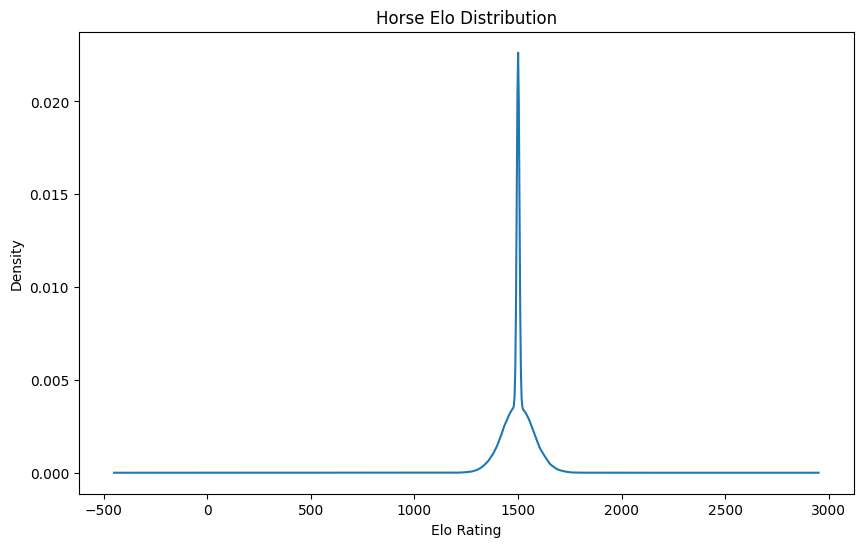

In [ ]:

model_df["horse_elo_before"].plot(
    kind="density",
    figsize=(10, 6)
)

plt.title("Horse Elo Distribution")
plt.xlabel("Elo Rating")

plt.show()

This KDE (Kernel Density Estimate) plot illustrates the distribution of horse Elo ratings before a race, showing the overall spread and density of Elo scores.

# Histogram + KDE Together

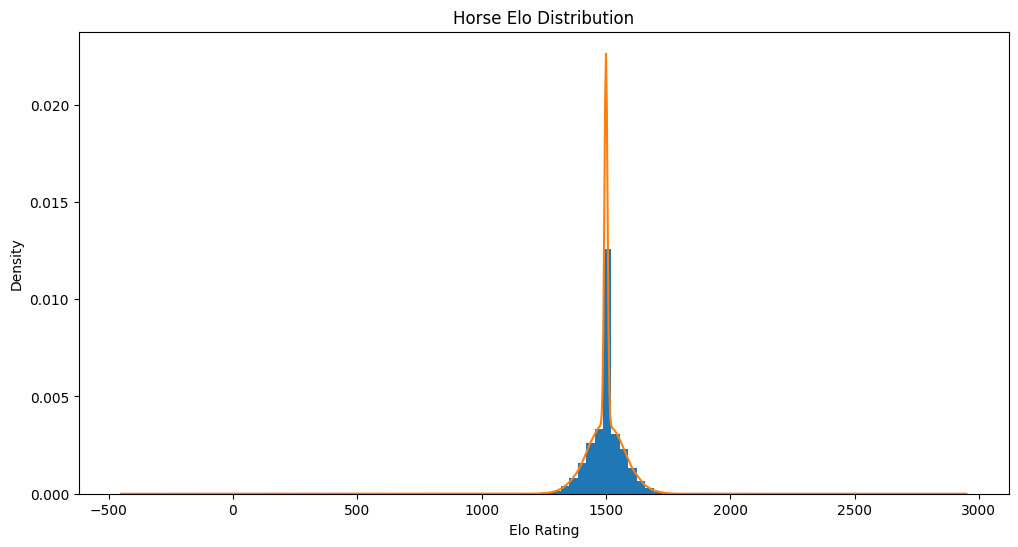

In [ ]:
plt.figure(figsize=(12, 6))

model_df["horse_elo_before"].hist(
    bins=50,
    density=True
)

model_df["horse_elo_before"].plot(
    kind="density"
)

plt.title("Horse Elo Distribution")
plt.xlabel("Elo Rating")

plt.show()

This combined plot shows both the histogram and the KDE curve of horse Elo ratings before a race, providing a comprehensive view of the distribution and density of Elo scores.

# Boxplot to see outliers

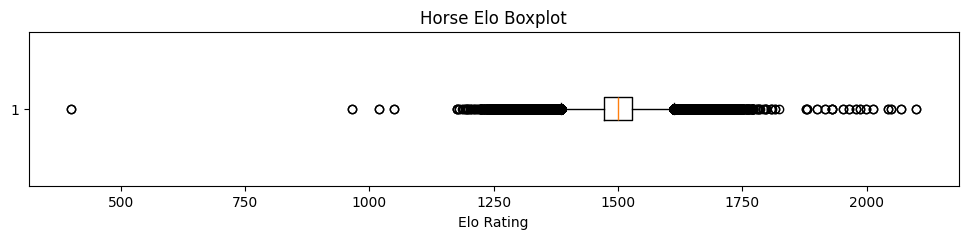

In [ ]:
plt.figure(figsize=(12, 2))

plt.boxplot(
    model_df["horse_elo_before"].dropna(),
    vert=False
)

plt.title("Horse Elo Boxplot")
plt.xlabel("Elo Rating")

plt.show()

This boxplot for horse Elo ratings visually identifies the median, quartiles, and potential outliers in the distribution of Elo scores.

In [ ]:
q1 = model_df["horse_elo_before"].quantile(0.25)
q3 = model_df["horse_elo_before"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", q1)
print("Median:", model_df["horse_elo_before"].median())
print("Q3:", q3)
print("IQR:", iqr)

print("Lower Outlier Bound:", lower_bound)
print("Upper Outlier Bound:", upper_bound)

Q1: 1471.1494213340184
Median: 1500.0
Q3: 1527.660477990146
IQR: 56.51105665612772
Lower Outlier Bound: 1386.382836349827
Upper Outlier Bound: 1612.4270629743378


# Elite/Outlier Horses

In [ ]:
model_df[
    model_df["horse_elo_before"] > upper_bound
][[
    "runner_horse",
    "horse_elo_before",
    "race_class",
    "runner_position"
]].sort_values("horse_elo_before", ascending=False)

,runner_horse,horse_elo_before,race_class,runner_position
71594,Numbers (NZ),2100.000000,Class 4,8
71593,King Of Thunder (NZ),2100.000000,Class 4,8
84088,Moon d'Orange (FR),2069.875702,0,5
84087,Moon D'Orange (FR),2069.875702,0,5
87108,Storm Piece (GB),2048.474903,0,3
...,...,...,...,...
94735,Lejolicoeur Du Mou (FR),1612.489077,Class 4,4
28847,Bint Al Daar (GB),1612.481268,0,1
57740,Arklow Lad (IRE),1612.479078,Class 4,6
28379,Fram Castle (IRE),1612.473329,0,6


# Distribution by race class

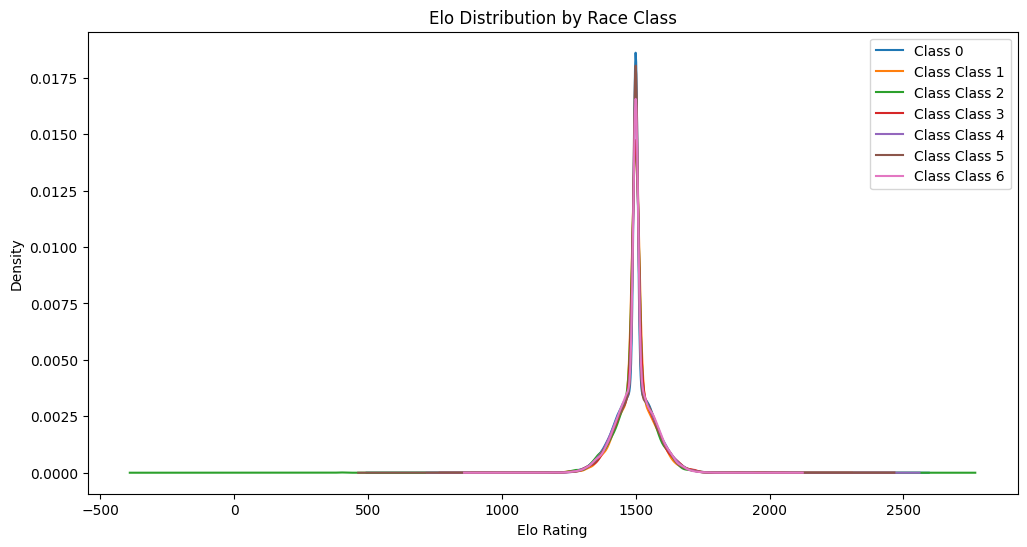

In [ ]:
# Convert race_class to string to ensure consistent sorting of mixed types (int and str)
classes = sorted(model_df["race_class"].astype(str).unique())

plt.figure(figsize=(12, 6))

for race_class in classes:
    subset = model_df[
        model_df["race_class"].astype(str) == race_class
    ]

    subset["horse_elo_before"].plot(
        kind="density",
        label=f"Class {race_class}"
    )

plt.legend()
plt.title("Elo Distribution by Race Class")
plt.xlabel("Elo Rating")
plt.show()

This density plot illustrates the distribution of Elo ratings for horses across different race classes, allowing for a comparison of Elo score ranges in various competition levels.

# Top Horse

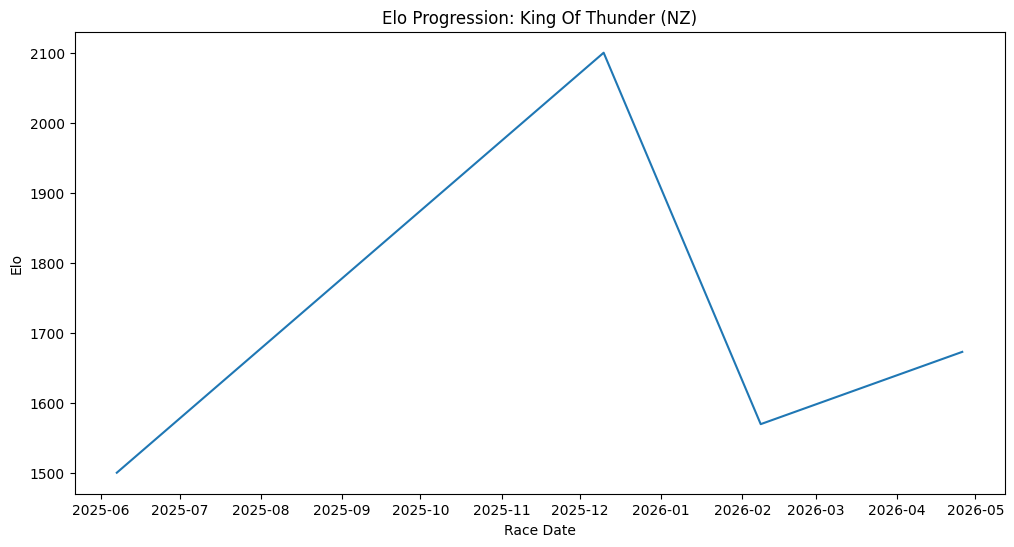

In [ ]:
top_horse = (
    model_df.groupby("runner_horse")["horse_elo_before"]
    .max()
    .idxmax()
)

horse_df = model_df[
    model_df["runner_horse"] == top_horse
].sort_values("race_date")

plt.figure(figsize=(12, 6))

plt.plot(
    horse_df["race_date"],
    horse_df["horse_elo_before"]
)

plt.title(f"Elo Progression: {top_horse}")
plt.xlabel("Race Date")
plt.ylabel("Elo")

plt.show()

This line plot displays the progression of the Elo rating over time for the horse with the highest maximum Elo score, showing how its rating evolved across different races.

# Distribution of Class 1,2,3 Horses

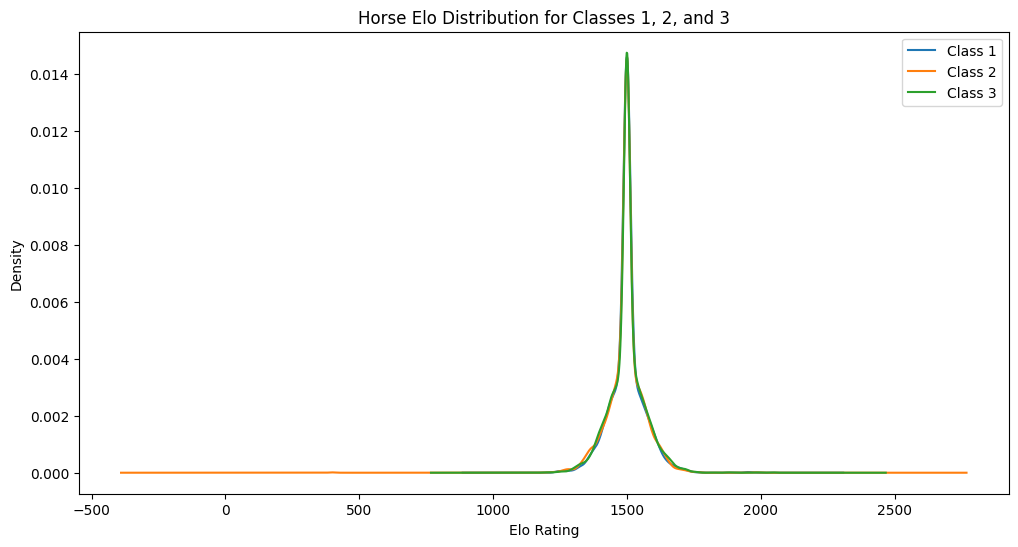

In [ ]:
plt.figure(figsize=(12, 6))

# Using string labels to match the data format in model_df
for race_class in ['Class 1', 'Class 2', 'Class 3']:
    subset = model_df[
        model_df["race_class"].astype(str) == race_class
    ]

    # Only plot if the subset actually contains data to avoid ValueErrors
    if not subset.empty:
        subset["horse_elo_before"].plot(
            kind="density",
            label=race_class
        )

plt.title("Horse Elo Distribution for Classes 1, 2, and 3")
plt.xlabel("Elo Rating")
plt.ylabel("Density")

plt.legend()
plt.show()

This density plot compares the distribution of horse Elo ratings specifically for Class 1, Class 2, and Class 3 races, highlighting the typical Elo ranges for top-tier competitions.

In [ ]:
model_df.columns

Index(['runner_horse', 'race_region', 'race_course', 'race_type', 'race_class',
       'race_going', 'race_surface', 'runner_age', 'runner_sex',
       'runner_weight_lbs', 'runner_draw', 'runner_headgear', 'runner_or',
       'runner_rpr', 'runner_tsr', 'runner_sp_dec', 'runner_bsp',
       'runner_jockey', 'runner_trainer', 'runner_position',
       'race_dist_meters', 'distance_category', 'winner', 'race_race_id',
       'runner_horse_id', 'sire_win_rate', 'sire_avg_rpr', 'sire_avg_tsr',
       'sire_sample_size', 'damsire_win_rate', 'damsire_avg_rpr',
       'damsire_avg_tsr', 'damsire_sample_size', 'dam_win_rate', 'dam_avg_rpr',
       'dam_avg_tsr', 'dam_sample_size', 'pedigree_score', 'race_date',
       'horse_elo_before', 'horse_elo_rank', 'horse_elo_vs_race_avg'],
      dtype='object')

In [ ]:
model_df.size

4961292

Boxplot of winners and elo

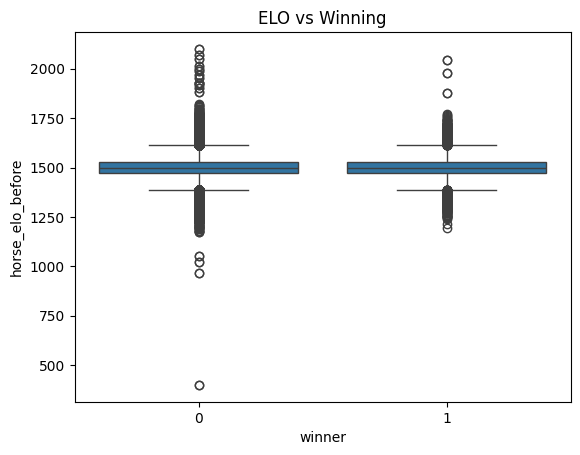

In [ ]:
sns.boxplot(
    x='winner',
    y='horse_elo_before',
    data=model_df
)

plt.title('ELO vs Winning')
plt.show()

This boxplot shows the distribution of horse Elo ratings for winners versus non-winners, indicating if horses with higher Elo ratings are more likely to win.

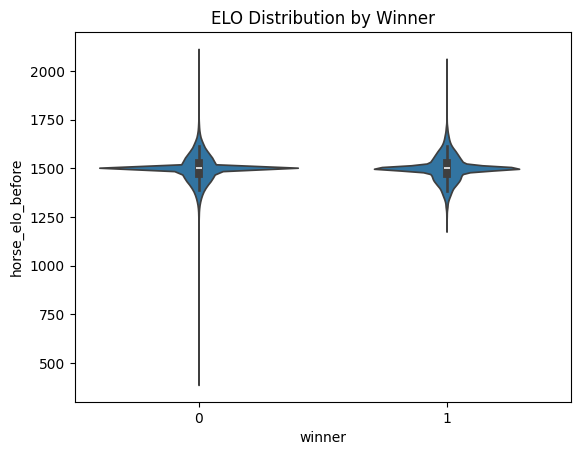

In [ ]:
sns.violinplot(
    x='winner',
    y='horse_elo_before',
    data=model_df
)

plt.title("ELO Distribution by Winner")
plt.show()

This violin plot visualizes the density and distribution of Elo ratings for winners and non-winners. While the medians are similar, winners show a slightly different density profile in the higher Elo ranges.

An elo rating system was implemented to capture horse performance trends over time. Due to the limited historical dataset (1 year of racing), elo ratings remained relatively concentrated around their initial value and demonstrated limited standalone predictive power. However, the feature was retained as it may provide additional signal when combined with traditional perofrmance metrics such as TSR, RPR and Official Rating

In [ ]:
model_df['elo_bucket'] = pd.cut(
    model_df['horse_elo_before'],
    bins=[0,1300,1400,1500,1600,1700,2500]
)

win_rates = (
    model_df.groupby('elo_bucket')['winner']
    .mean()
)

print(win_rates)

elo_bucket
(0, 1300]       0.088015
(1300, 1400]    0.102255
(1400, 1500]    0.099800
(1500, 1600]    0.100936
(1600, 1700]    0.096456
(1700, 2500]    0.113680
Name: winner, dtype: float64


/tmp/ipykernel_44336/2355137949.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



# Pedigree Analysis

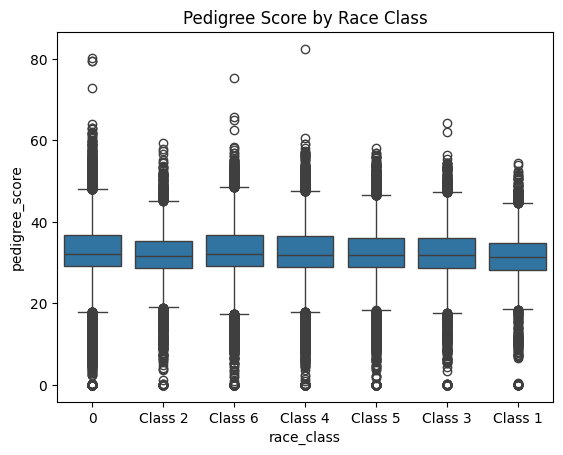

In [ ]:
sns.boxplot(
    x='race_class',
    y='pedigree_score',
    data=model_df
)

plt.title("Pedigree Score by Race Class")
plt.show()

This boxplot visualizes the pedigree score distribution across different race classes, examining whether horses in higher classes tend to have different pedigree scores.

In [ ]:
model_df['pedigree_quartile'] = pd.qcut(
    model_df['pedigree_score'],
    4,
    labels=['Q1','Q2','Q3','Q4']
)

(
    model_df.groupby('pedigree_quartile')['winner']
    .mean()
)

/tmp/ipykernel_44336/3194350131.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,winner
pedigree_quartile,
Q1,0.100163
Q2,0.100945
Q3,0.101317
Q4,0.097860


Pedigree-based features were engineered using sire and damsire and dam historical performance metrics. Exploratory analysis showed that the aggregated pedigree score exhibited minimal correlation with winning outcomes within the one-year dataset. This suggests pedigree information alone may not be a strong predictor of race success, though individual pedigree attributes were retained for further model evaluation.

# Since Horse Racing is Relative Race-Level Features

In [ ]:
model_df['or_rank'] = (
    model_df.groupby('race_race_id')['runner_or']
    .rank(ascending=False)
)

model_df['rpr_rank'] = (
    model_df.groupby('race_race_id')['runner_rpr']
    .rank(ascending=False)
)

model_df['tsr_rank'] = (
    model_df.groupby('race_race_id')['runner_tsr']
    .rank(ascending=False)
)

In [ ]:
model_df.groupby('or_rank')['winner'].mean()

,winner
or_rank,
1.0,0.153779
1.5,0.114217
2.0,0.119505
2.5,0.097793
3.0,0.105625
3.5,0.094605
4.0,0.086190
4.5,0.093432
5.0,0.091447


In [ ]:
overall_win_rate = model_df['winner'].mean()
print(overall_win_rate)

0.10007111050911738


In [ ]:
model_df.groupby('rpr_rank')['winner'].mean()

,winner
rpr_rank,
1.0,0.393559
1.5,0.223634
2.0,0.141143
2.5,0.113898
3.0,0.075539
3.5,0.074437
4.0,0.056829
4.5,0.058602
5.0,0.041359


In [ ]:
model_df.groupby('tsr_rank')['winner'].mean()

,winner
tsr_rank,
1.0,0.356830
1.5,0.241993
2.0,0.143035
2.5,0.117989
3.0,0.081981
3.5,0.076841
4.0,0.066973
4.5,0.057093
5.0,0.048549


In [ ]:
model_df['elo_rank'] = (
    model_df.groupby('race_race_id')['horse_elo_before']
    .rank(ascending=False)
)

model_df.groupby('elo_rank')['winner'].mean().head(10)

elo_rank1_winrate = (
    model_df.groupby('elo_rank')['winner']
    .mean()
    .loc[1.0]
)

lift = elo_rank1_winrate / model_df['winner'].mean()

print(lift)

1.1135666502750765


if we divide OR Rrank TSR Rank & RPR Rank by average win rate then we can see that


*   OR  Rank 1 Lift = 1.54x
*   RPR Rank 1 Lift = 3.93x
*   TSR Rank 1 Lift = 3.57x
*   ELO Rank 1 Lift = 1.11x




# Relative Race Metrics Heat Map

<Axes: >

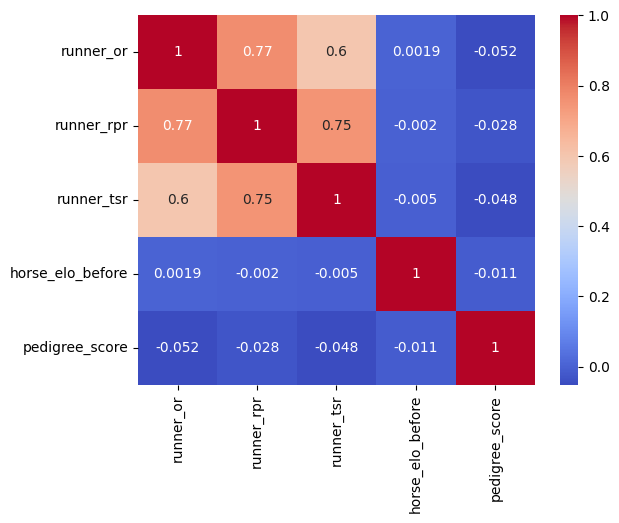

In [ ]:
cols = [
    'runner_or',
    'runner_rpr',
    'runner_tsr',
    'horse_elo_before',
    'pedigree_score'
]

sns.heatmap(
    model_df[cols].corr(),
    annot=True,
    cmap='coolwarm'
)

This heatmap specifically looks at the correlation between horse ratings, pedigree scores, and Elo ratings. It confirms that pedigree and Elo are relatively independent of traditional ratings like OR and RPR in this dataset.

confirms the bias against elo and pedigree score due to limited scope

# Check for missing data

In [ ]:
model_df.isnull().sum().sort_values(ascending=False)

,0
runner_or,39126
or_rank,39126
tsr_rank,31118
runner_tsr,31118
runner_rpr,22842
rpr_rank,22842
race_class,0
runner_horse,0
runner_age,0
race_surface,0


In [ ]:
len(model_df)

118126

In [ ]:
model_df['runner_rpr'].isnull().groupby(model_df['winner']).mean()

,runner_rpr
winner,
0,0.198420
1,0.147957


In [ ]:
model_df['runner_tsr'].isnull().groupby(model_df['winner']).mean()

,runner_tsr
winner,
0,0.272029
1,0.186109


In [ ]:
model_df['rpr_missing'] = (
    model_df['runner_rpr'].isna()
).astype(int)

model_df['tsr_missing'] = (
    model_df['runner_tsr'].isna()
).astype(int)

model_df['or_missing'] = (
    model_df['runner_or'].isna()
).astype(int)

In [ ]:
model_df['runner_rpr'] = model_df['runner_rpr'].fillna(-1)
model_df['runner_tsr'] = model_df['runner_tsr'].fillna(-1)
model_df['runner_or'] = model_df['runner_or'].fillna(-1)

In [ ]:
model_df.isnull().sum().sort_values(ascending=False)

,0
or_rank,39126
tsr_rank,31118
rpr_rank,22842
race_type,0
race_class,0
race_going,0
race_surface,0
runner_age,0
runner_sex,0
runner_weight_lbs,0


In [ ]:
model_df['or_rank'] = (
    model_df.groupby('race_race_id')['runner_or']
    .rank(ascending=False)
)

model_df['rpr_rank'] = (
    model_df.groupby('race_race_id')['runner_rpr']
    .rank(ascending=False)
)

model_df['tsr_rank'] = (
    model_df.groupby('race_race_id')['runner_tsr']
    .rank(ascending=False)
)

model_df['elo_rank'] = (
    model_df.groupby('race_race_id')['horse_elo_before']
    .rank(ascending=False)
)

In [ ]:
model_df[
    ['or_rank','rpr_rank','tsr_rank','elo_rank']
].isnull().sum()

,0
or_rank,0
rpr_rank,0
tsr_rank,0
elo_rank,0


added a missing feature after filling missing values

# Choose to fill sample size counts with the median

In [ ]:
model_df['damsire_sample_size'] = (
    model_df['damsire_sample_size']
    .fillna(model_df['damsire_sample_size'].median())
)

model_df['dam_sample_size'] = (
    model_df['dam_sample_size']
    .fillna(model_df['dam_sample_size'].median())
)

In [ ]:
model_df.isnull().sum().sort_values(ascending=False)

,0
runner_horse,0
race_region,0
race_course,0
race_type,0
race_class,0
race_going,0
race_surface,0
runner_age,0
runner_sex,0
runner_weight_lbs,0


# EDA Key Findings

Several important insights

1.   Dynamic performance metrics such as RPR and TSR appear more predictive than static handicap ratings alone
1.   Betting odds already encode significant predictive information and should be included as major model features
2.   Race conditions such as surface type and race distance strongly influence horse performance
2.   Horse demographics including age and gender contribute meaningful contextual information
1.   the dataset contains substanitial international diversity, improving the potential generalizability of ML models
1.   Pedigree based features created for sire/damsire/dam to observe bloodlines consistently outperforming others, larger pedigree sample sizes provide more reliable predictive signals and pedigree performance varies across race conditions and class levels

1.   A dynamic Elo rating system was implemented to estimate horse racing strenght over time
2.  Elo distributions align closely with race class quality and captures both recent and competition-adjusted strengths more effecitvely
1.  Engineered features designed to improve the dataset's predictive depth beyond raw race results
2.   Strong relationships between: Horse ratings, pedigree, betting odds, race class, historical form, elo strength ratings and race outcome


1.   Elo and Pedigree were not as strong predictors as I thought they'd be given the 1 year's worth of data but kept them in
2.   OR, RPR, & TSR Lift showed meaningful insight on how much higher the #1 rank horse of the given stat is to win against the average horse




# Remove Target Feature from the Data Matrix

In [ ]:
model_df.drop(columns=["runner_position"])

,runner_horse,race_region,race_course,race_type,race_class,race_going,race_surface,runner_age,runner_sex,runner_weight_lbs,...,horse_elo_vs_race_avg,elo_bucket,pedigree_quartile,or_rank,rpr_rank,tsr_rank,elo_rank,rpr_missing,tsr_missing,or_missing
8,Sean (GER),FR,Compiegne (FR),Flat,0,Heavy,Turf,7,G,148,...,0.000000,"(1400, 1500]",Q1,2.5,1.0,2.5,2.5,0,1,1
9,Talis Evolvere (IRE),FR,Compiegne (FR),Flat,0,Heavy,Turf,7,G,150,...,0.000000,"(1400, 1500]",Q1,2.5,2.0,2.5,2.5,0,1,1
10,Sterling Knight (GB),FR,Compiegne (FR),Flat,0,Heavy,Turf,5,G,150,...,0.000000,"(1400, 1500]",Q1,2.5,3.0,2.5,2.5,0,1,1
12,Native Warrior (GB),FR,Compiegne (FR),Flat,0,Heavy,Turf,8,M,154,...,0.000000,"(1400, 1500]",Q1,2.5,4.0,2.5,2.5,0,1,1
75,Indian Creak (IRE),GB,Redcar,Flat,Class 2,Good To Firm,Turf,4,G,138,...,0.000000,"(1400, 1500]",Q1,1.0,1.0,1.0,1.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118091,Happy Mum's Day (FR),GB,Bath,Flat,Class 6,Firm,Turf,4,G,137,...,11.599536,"(1500, 1600]",Q4,2.0,5.0,5.0,2.0,1,1,0
118092,Heart And Soul (FR),GB,Redcar,Flat,Class 4,Good To Firm,Turf,2,F,128,...,30.153566,"(1500, 1600]",Q3,7.0,5.0,5.0,1.0,1,1,1
118093,Maharaja Rochelais (FR),GB,Redcar,Flat,Class 4,Good To Firm,Turf,2,F,122,...,2.577864,"(1400, 1500]",Q3,7.0,5.0,5.0,5.0,1,1,1
118094,Memoire Du Large (FR),GB,Redcar,Flat,Class 4,Good To Firm,Turf,2,F,128,...,2.577864,"(1400, 1500]",Q4,7.0,5.0,5.0,5.0,1,1,1


# Save a copy of the clean_csv



In [ ]:
base_path = "/content/drive/MyDrive/EquiMetrics"

Path(f"{base_path}/clean_data").mkdir(parents=True, exist_ok=True)

model_df.to_csv(
    f"{base_path}/clean_data/clean_data.csv",
    index=False
)

# Split Data


In [ ]:
base_path = "/content/drive/MyDrive/EquiMetrics"

Path(f"{base_path}/training_data").mkdir(parents=True, exist_ok=True)
Path(f"{base_path}/testing_data").mkdir(parents=True, exist_ok=True)

train_df, test_df = train_test_split(
    model_df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

train_df.to_csv(
    f"{base_path}/training_data/train_data.csv",
    index=False
)

test_df.to_csv(
    f"{base_path}/testing_data/test_data.csv",
    index=False
)

print("Files saved successfully.")

Files saved successfully.


80% training data / 20% testing data

### Data Leakage Audit
To ensure our model is valid, we must confirm that every feature used was known *before* the race started.

**Safe Features:**
*   `horse_elo_before`: Explicitly uses the rating from prior to the current race.
*   `sire_win_rate` / `dam_win_rate`: Calculated using `.shift(1)`, meaning they only include past races.
*   `runner_age`, `race_dist_meters`, `race_surface`: Known characteristics of the horse and race.

**Potential Risks:**
*   `runner_sp_dec`: This is the final price at the jump. While available 'at start', in a real-time production system, you'd only have 'current' odds. It's safe for research but important to note.
*   `runner_position`: This is our **Target (Y)** and must be dropped from the **Feature matrix (X)** during training.

In [ ]:
# Final check for columns that definitely shouldn't be in a training set
leakage_candidates = ['runner_position', 'winner', 'runner_time', 'race_winning_time_detail', 'runner_comment']
found_leakage = [c for c in leakage_candidates if c in train_df.columns and c not in ['runner_position', 'winner']]

if found_leakage:
    print(f"WARNING: Potential leakage features found: {found_leakage}")
else:
    print("Leakage check passed: No post-race performance metrics found in training features (excluding targets).")

Leakage check passed: No post-race performance metrics found in training features (excluding targets).


I removed runner_position several slides ups

# Decision Tree as a baseline

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score

In [ ]:
dt_train_df = pd.read_csv("/content/drive/MyDrive/EquiMetrics/training_data/train_data.csv")
dt_test_df = pd.read_csv("/content/drive/MyDrive/EquiMetrics/testing_data/test_data.csv")

remove_cols = [
    "race_race_id",
    "runner_horse_id",
    "runner_horse",
    "winner",
    "runner_position"
]

# Features
X_train = dt_train_df.drop(columns=remove_cols, errors="ignore")
X_test = dt_test_df.drop(columns=remove_cols, errors="ignore")

# Target
y_train = dt_train_df["winner"]
y_test = dt_test_df["winner"]

Set Features and Target

In [ ]:
X_train.select_dtypes(include="object").columns

Index(['race_region', 'race_course', 'race_type', 'race_class', 'race_going',
       'race_surface', 'runner_sex', 'runner_headgear', 'runner_jockey',
       'runner_trainer', 'distance_category', 'race_date', 'elo_bucket',
       'pedigree_quartile'],
      dtype='object')

Remove data that can't be processed by decision tree race_date and make every other categorical string into numeric dummies

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Drop 'race_date' as it cannot be processed by the model
X_train = X_train.drop(columns=['race_date'], errors='ignore')
X_test = X_test.drop(columns=['race_date'], errors='ignore')

# Convert categorical strings into numeric dummies directly into X_train and X_test
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Align columns to ensure consistency
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

tree_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=20,
    random_state=42
)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predictions
dt_pred = tree_model.predict(X_test)
dt_proba = tree_model.predict_proba(X_test)[:, 1]
dt_logloss = log_loss(y_test,dt_proba)
# Metrics
print(f"Accuracy: {accuracy_score(y_test, dt_pred):.4f}")
print(f"Precision: {precision_score(y_test, dt_pred):.4f}")
print(f"Recall: {recall_score(y_test, dt_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, dt_pred):.4f}")
print(f"Log Loss: {dt_logloss:.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, dt_proba):.4f}")

Accuracy: 0.9162
Precision: 0.6749
Recall: 0.3489
F1 Score: 0.4600
Log Loss: 0.2357
ROC AUC: 0.8802


Calculate Top-1 Accuracy and the NDCGs

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import ndcg_score

def ranking_metrics_by_race(test_df, pred_scores):
    eval_df = test_df[["race_key", "runner_position"]].copy()

    eval_df["finish_pos"] = pd.to_numeric(
        eval_df["runner_position"],
        errors="coerce"
    ).fillna(40)

    eval_df["field_size"] = eval_df.groupby("race_key")["race_key"].transform("count")

    # Higher label = better finish
    eval_df["rank_label"] = (
        eval_df["field_size"] - eval_df["finish_pos"] + 1
    ).clip(lower=0)

    eval_df["pred_score"] = pred_scores

    top1_correct = 0
    valid_races = 0

    ndcg3_scores = []
    ndcg5_scores = []
    ndcg10_scores = []

    for _, race in eval_df.groupby("race_key"):
        if len(race) < 2:
            continue

        y_true = race["rank_label"].to_numpy()
        y_pred = race["pred_score"].to_numpy()

        top1_correct += int(np.argmax(y_pred) == np.argmax(y_true))
        valid_races += 1

        ndcg3_scores.append(ndcg_score([y_true], [y_pred], k=3))
        ndcg5_scores.append(ndcg_score([y_true], [y_pred], k=5))
        ndcg10_scores.append(ndcg_score([y_true], [y_pred], k=10))

    return {
        "top1_accuracy": top1_correct / valid_races,
        "ndcg@3": np.mean(ndcg3_scores),
        "ndcg@5": np.mean(ndcg5_scores),
        "ndcg@10": np.mean(ndcg10_scores)
    }

In [ ]:
# Decision Tree
# Ensure race_key and race_date are available and correctly formatted in dt_test_df
if 'race_date' in dt_test_df.columns:
    dt_test_df['race_date'] = pd.to_datetime(dt_test_df['race_date'])
    dt_test_df['race_key'] = dt_test_df['race_race_id'].astype(str) + "_" + dt_test_df['race_date'].dt.strftime("%Y-%m-%d")
else:
    print("Warning: 'race_date' not found in dt_test_df. Cannot create 'race_key' reliably.")

dt_scores = tree_model.predict_proba(X_test)[:, 1]

dt_rank_metrics = ranking_metrics_by_race(
    dt_test_df,
    dt_scores
)

dt_rank_metrics

{'top1_accuracy': 0.6087213599408722,
 'ndcg@3': np.float64(0.4838239772562985),
 'ndcg@5': np.float64(0.49334800925648564),
 'ndcg@10': np.float64(0.4942685319107339)}

Decision Tree
*   top1_accuracy: 0.6087213599408722
*   ndcg@3: np.float64(0.4838239772562985)
*   ndcg@5: np.float64(0.49334800925648564)
*   ndcg@10: np.float64(0.4942685319107339)

While the model demonstrated strong discriminatory power and produced well-calibrated probability estimates, recall remained relatively low, indicating that many winning horses were not identified. These results establish a baseline for comparison with more advanced ensemble methods such as Random Forest, XGBoost, LightGBM, and CatBoost.


# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier


Since random forest is a collection of Decision Trees we can use the same variables from the Decision Tree, but we will adjust the hyperparameters acordingly

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    random_state=42
    )

rf_model.fit(X_train, y_train)

RandomForestClassifier(min_samples_leaf=5, n_estimators=300, random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import ndcg_score

def ranking_metrics_by_race(test_df, pred_scores):
    eval_df = test_df[["race_key", "runner_position"]].copy()

    eval_df["finish_pos"] = pd.to_numeric(
        eval_df["runner_position"],
        errors="coerce"
    ).fillna(40)

    eval_df["field_size"] = eval_df.groupby("race_key")["race_key"].transform("count")

    # Higher label = better finish
    eval_df["rank_label"] = (
        eval_df["field_size"] - eval_df["finish_pos"] + 1
    ).clip(lower=0)

    eval_df["pred_score"] = pred_scores

    top1_correct = 0
    valid_races = 0

    ndcg3_scores = []
    ndcg5_scores = []
    ndcg10_scores = []

    for _, race in eval_df.groupby("race_key"):
        if len(race) < 2:
            continue

        y_true = race["rank_label"].to_numpy()
        y_pred = race["pred_score"].to_numpy()

        top1_correct += int(np.argmax(y_pred) == np.argmax(y_true))
        valid_races += 1

        ndcg3_scores.append(ndcg_score([y_true], [y_pred], k=3))
        ndcg5_scores.append(ndcg_score([y_true], [y_pred], k=5))
        ndcg10_scores.append(ndcg_score([y_true], [y_pred], k=10))

    return {
        "top1_accuracy": top1_correct / valid_races,
        "ndcg@3": np.mean(ndcg3_scores),
        "ndcg@5": np.mean(ndcg5_scores),
        "ndcg@10": np.mean(ndcg10_scores)
    }

In [ ]:
 # Random Forest
rf_scores = rf_model.predict_proba(X_test)[:, 1]

rf_rank_metrics = ranking_metrics_by_race(
    dt_test_df,
    rf_scores
)

rf_rank_metrics

{'top1_accuracy': 0.588470066518847,
 'ndcg@3': np.float64(0.4862623256551165),
 'ndcg@5': np.float64(0.4945243820581111),
 'ndcg@10': np.float64(0.495306016678589)}

In [ ]:
rf_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

rf_importance_df.head(20)

,Feature,Importance
26,rpr_rank,0.166616
6,runner_sp_dec,0.126307
27,tsr_rank,0.120869
4,runner_rpr,0.098978
7,runner_bsp,0.050513
5,runner_tsr,0.046641
3,runner_or,0.017073
25,or_rank,0.013980
1,runner_weight_lbs,0.010391
2,runner_draw,0.010257


In [ ]:
pd.Series(rf_proba).describe()

,0
count,23626.000000
mean,0.099276
std,0.079425
min,0.011757
25%,0.045044
50%,0.071489
75%,0.126568
max,0.493663


The stats that matter for Random Forest

*   top1_accuracy : 0.588470066518847
*   ndcg@3        : 0.4862623256551165
*   ndcg@5        : 0.4945243820581111
*   ndcg@10       : 0.495306016678589




# XGBoost

In [ ]:
!pip install xgboost -q

In [5]:
from xgboost import XGBRanker
from xgboost import XGBRegressor
from sklearn.model_selection import GroupShuffleSplit
from itertools import product
import pandas as pd
import requests
from sklearn.model_selection import train_test_split
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Grab data from drive

In [6]:
import pandas as pd

xgb_train = pd.read_csv("/content/drive/MyDrive/EquiMetrics/training_data/train_data.csv")
xgb_test = pd.read_csv("/content/drive/MyDrive/EquiMetrics/testing_data/test_data.csv")

print(xgb_train.shape)
print(xgb_test.shape)

(94500, 51)
(23626, 51)


In [7]:
# Create race_key if it does not exist
for df in [xgb_train, xgb_test]:
    if "race_key" not in df.columns:
        df["race_key"] = (
            df["race_race_id"].astype(str)
            + "_"
            + pd.to_datetime(df["race_date"]).dt.strftime("%Y-%m-%d")
        )
print(xgb_train.shape)
print(xgb_test.shape)

(94500, 52)
(23626, 52)


Create Ranking Label

In [8]:
def add_rank_label(df):
    df["finish_pos"] = pd.to_numeric(
        df["runner_position"],
        errors="coerce"
    ).fillna(40).astype("int16")

    df["field_size"] = (
        df.groupby("race_key")["race_key"]
        .transform("count")
        .astype("int16")
    )

    # Higher = better
    df["rank_label"] = (
        df["field_size"] - df["finish_pos"] + 1
    ).clip(lower=0).astype("int16")

    return df

xgb_train = add_rank_label(xgb_train)
xgb_test = add_rank_label(xgb_test)

Sory by Race

In [9]:
xgb_train = xgb_train.sort_values(["race_key", "rank_label"], ascending=[True, False]).reset_index(drop=True)
xgb_test = xgb_test.sort_values(["race_key", "rank_label"], ascending=[True, False]).reset_index(drop=True)

Save Evaluation info

In [10]:
xgb_eval = xgb_test[[
    "race_key",
    "winner",
    "rank_label"
]].copy()

Create Group sizes

In [11]:
group_train = xgb_train.groupby("race_key").size().to_numpy()
group_test = xgb_test.groupby("race_key").size().to_numpy()

print("Train races:", len(group_train))
print("Test races:", len(group_test))
print("Train rows from groups:", group_train.sum())
print("Test rows from groups:", group_test.sum())

Train races: 15178
Test races: 11423
Train rows from groups: 94500
Test rows from groups: 23626


In [12]:
print(len(xgb_train))
print(len(xgb_test))

94500
23626


Prepare features

In [13]:
drop_cols = [
    "winner",
    "runner_position",
    "finish_pos",
    "field_size",
    "rank_label",
    "race_race_id",
    "race_date",
    "race_key",
    "runner_horse",
    "runner_horse_id"
]

X_train = xgb_train.drop(columns=[c for c in drop_cols if c in xgb_train.columns])
X_test = xgb_test.drop(columns=[c for c in drop_cols if c in xgb_test.columns])

y_train = xgb_train["rank_label"]
y_test = xgb_test["rank_label"]

print(X_train.shape)
print(X_test.shape)

(94500, 45)
(23626, 45)


Encode categoricals

In [14]:
train_len = len(X_train)

combined = pd.concat([X_train, X_test], axis=0, ignore_index=True)

combined = pd.get_dummies(
    combined,
    drop_first=True,
    dtype="uint8"
)

X_train = combined.iloc[:train_len]
X_test = combined.iloc[train_len:]

del combined

print(X_train.shape)
print(X_test.shape)

(94500, 5349)
(23626, 5349)


In [15]:
import re

def clean_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = re.sub(r'[^A-Za-z0-9_]+', '', col) # Remove special characters
        new_cols.append(new_col)
    df.columns = new_cols
    return df

X_train = clean_col_names(X_train)
X_test = clean_col_names(X_test)

checking each model dataframe

In [19]:
def check_rank_label_setup(name, df):
    print(f"\n{name}")
    print("Rows:", len(df))
    print("Has race_key:", "race_key" in df.columns)
    print("Has rank_label:", "rank_label" in df.columns)

    if "rank_label" in df.columns:
        print("rank_label min:", df["rank_label"].min())
        print("rank_label max:", df["rank_label"].max())
        print("rank_label dtype:", df["rank_label"].dtype)
        print("rank_label sample:")
        print(df[["race_key", "runner_position", "rank_label"]].head(10))

    print("Winners per race:")
    print(
        df.groupby("race_key")["winner"]
        .sum()
        .value_counts()
        .sort_index()
        .head()
    )

Train XGBoost Ranker

In [16]:
xgb_ranker = XGBRanker(
    objective="rank:ndcg",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_ranker.fit(
    X_train,
    y_train,
    group=group_train
)

XGBRanker(base_score=None, booster=None, callbacks=None, colsample_bylevel=None,
          colsample_bynode=None, colsample_bytree=0.8, device=None,
          early_stopping_rounds=None, enable_categorical=False,
          eval_metric=None, feature_types=None, feature_weights=None,
          gamma=None, grow_policy=None, importance_type=None,
          interaction_constraints=None, learning_rate=0.05, max_bin=None,
          max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=None,
          max_depth=6, max_leaves=None, min_child_weight=None, missing=nan,
          monotone_constraints=None, multi_strategy=None, n_estimators=500,
          n_jobs=-1, num_parallel_tree=None, ...)

Predictions

In [17]:
from sklearn.metrics import ndcg_score
import numpy as np
import pandas as pd

def ranking_metrics_by_race(eval_df, scores):

    df = eval_df.copy()
    df["score"] = scores

    top1_correct = 0

    ndcg_3_scores = []
    ndcg_5_scores = []
    ndcg_10_scores = []

    valid_races = 0

    for _, race in df.groupby("race_key"):

        if len(race) < 2:
            continue

        valid_races += 1

        y_true = race["rank_label"].values
        y_pred = race["score"].values

        # Top-1 Accuracy
        predicted_winner = np.argmax(y_pred)
        actual_winner = np.argmax(y_true)

        if predicted_winner == actual_winner:
            top1_correct += 1

        ndcg_3_scores.append(
            ndcg_score([y_true], [y_pred], k=3)
        )

        ndcg_5_scores.append(
            ndcg_score([y_true], [y_pred], k=5)
        )

        ndcg_10_scores.append(
            ndcg_score([y_true], [y_pred], k=10)
        )

    return {
        "top1_accuracy": top1_correct / valid_races,
        "ndcg@3": np.mean(ndcg_3_scores),
        "ndcg@5": np.mean(ndcg_5_scores),
        "ndcg@10": np.mean(ndcg_10_scores)
    }

In [18]:
xgb_rank_scores = xgb_ranker.predict(X_test)

xgb_rank_metrics = ranking_metrics_by_race(
    xgb_eval,
    xgb_rank_scores
)

xgb_rank_metrics

{'top1_accuracy': 0.6532150776053215,
 'ndcg@3': np.float64(0.5143513851147152),
 'ndcg@5': np.float64(0.518170516797983),
 'ndcg@10': np.float64(0.5185059476054521)}

# LightGBM Ranker

In [ ]:
!pip install lightgbm

In [26]:
from lightgbm import LGBMRanker
from sklearn.metrics import ndcg_score

reload data

In [25]:
import pandas as pd

# Load full clean dataset
full_df = pd.read_csv(
    "/content/drive/MyDrive/EquiMetrics/clean_data/clean_data.csv"
)

# Make date usable
full_df["race_date"] = pd.to_datetime(full_df["race_date"])

# Recreate winner safely
full_df["winner"] = (
    pd.to_numeric(full_df["runner_position"], errors="coerce") == 1
).astype(int)

# Create a safer unique race key
full_df["race_key"] = (
    full_df["race_race_id"].astype(str)
    + "_"
    + full_df["race_date"].astype(str)
)

# Sort chronologically
full_df = full_df.sort_values("race_date").reset_index(drop=True)

# Get one date per race_key
race_dates = (
    full_df
    .groupby("race_key")["race_date"]
    .first()
    .sort_values()
)

# Chronological 80/20 split
cutoff_idx = int(len(race_dates) * 0.80)

train_races = race_dates.index[:cutoff_idx]
test_races = race_dates.index[cutoff_idx:]

lgbm_train_df = full_df[full_df["race_key"].isin(train_races)].copy()
lgbm_test_df = full_df[full_df["race_key"].isin(test_races)].copy()

# Verify
print("Train rows:", len(lgbm_train_df))
print("Test rows:", len(lgbm_test_df))

print("Train dates:")
print(lgbm_train_df["race_date"].min(), "to", lgbm_train_df["race_date"].max())

print("Test dates:")
print(lgbm_test_df["race_date"].min(), "to", lgbm_test_df["race_date"].max())

overlap = set(lgbm_train_df["race_key"]) & set(lgbm_test_df["race_key"])
print("Overlapping races:", len(overlap))

print(
    lgbm_test_df.groupby("race_key")["winner"]
    .sum()
    .value_counts()
    .sort_index()
)

Train rows: 95193
Test rows: 22933
Train dates:
2025-05-26 00:00:00 to 2026-03-21 00:00:00
Test dates:
2026-03-21 00:00:00 to 2026-05-26 00:00:00
Overlapping races: 0
winner
0    1223
1    1493
2     305
3      44
4       5
Name: count, dtype: int64


In [27]:
print(
    lgbm_test_df["winner"].value_counts()
)

print(
    lgbm_test_df.groupby("race_race_id")["winner"].sum().value_counts()
)

winner
0    20678
1     2255
Name: count, dtype: int64
winner
1    1493
0    1223
2     305
3      44
4       5
Name: count, dtype: int64


verify if in chronological order

In [28]:
print("Train rows:", len(lgbm_train_df))
print("Test rows:", len(lgbm_test_df))

print("\nTrain dates:")
print(lgbm_train_df["race_date"].min())
print(lgbm_train_df["race_date"].max())

print("\nTest dates:")
print(lgbm_test_df["race_date"].min())
print(lgbm_test_df["race_date"].max())

overlap = (
    set(lgbm_train_df["race_race_id"])
    & set(lgbm_test_df["race_race_id"])
)

print("\nOverlapping races:", len(overlap))

Train rows: 95193
Test rows: 22933

Train dates:
2025-05-26 00:00:00
2026-03-21 00:00:00

Test dates:
2026-03-21 00:00:00
2026-05-26 00:00:00

Overlapping races: 0


Create Ranking Target

In [29]:
def create_relevance(pos):
    if pos == 1:
        return 5
    elif pos == 2:
        return 3
    elif pos == 3:
        return 2
    else:
        return 0

lgbm_train_df["relevance"] = (
    lgbm_train_df["runner_position"]
    .apply(create_relevance)
)

lgbm_test_df["relevance"] = (
    lgbm_test_df["runner_position"]
    .apply(create_relevance)
)

In [30]:
X_train = lgbm_train_df.drop(
    columns=[
        "winner",
        "runner_position",
        "relevance"
    ]
)

X_test = lgbm_test_df.drop(
    columns=[
        "winner",
        "runner_position",
        "relevance"
    ]
)

y_train = lgbm_train_df["relevance"]
y_test = lgbm_test_df["relevance"]

Create group sizes

In [31]:
train_group = (
    lgbm_train_df
    .groupby("race_race_id")
    .size()
    .values
)

test_group = (
    lgbm_test_df
    .groupby("race_race_id")
    .size()
    .values
)

Group size validation

In [32]:
print("Train rows:", len(lgbm_train_df))
print("Train group sum:", train_group.sum())

print("Test rows:", len(lgbm_test_df))
print("Test group sum:", test_group.sum())

Train rows: 95193
Train group sum: 95193
Test rows: 22933
Test group sum: 22933


Create Features and Target

In [33]:
remove_cols = [
    "race_race_id",
    "runner_horse_id",
    "runner_horse",
    "winner",
    "runner_position",
    "relevance",
    "race_date"
]

X_train = lgbm_train_df.drop(
    columns=remove_cols,
    errors="ignore"
)

X_test = lgbm_test_df.drop(
    columns=remove_cols,
    errors="ignore"
)

y_train = lgbm_train_df["relevance"]
y_test = lgbm_test_df["relevance"]

In [34]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(95193, 46)
(22933, 46)
(95193,)
(22933,)


One-hot encoding

In [35]:
# LightGBM handles categorical features natively, which is much more memory-efficient than one-hot encoding.
categorical_cols = X_train.select_dtypes(include=['object']).columns

for col in categorical_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (95193, 46)
X_test shape: (22933, 46)


Encoder Checker

In [36]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("Train rows:", len(lgbm_train_df))
print("Test rows:", len(lgbm_test_df))

X_train: (95193, 46)
X_test: (22933, 46)
Train rows: 95193
Test rows: 22933


checking each model label setup

In [20]:
def check_rank_label_setup(name, df):
    print(f"\n{name}")
    print("Rows:", len(df))
    print("Has race_key:", "race_key" in df.columns)
    print("Has rank_label:", "rank_label" in df.columns)

    if "rank_label" in df.columns:
        print("rank_label min:", df["rank_label"].min())
        print("rank_label max:", df["rank_label"].max())
        print("rank_label dtype:", df["rank_label"].dtype)
        print("rank_label sample:")
        print(df[["race_key", "runner_position", "rank_label"]].head(10))

    print("Winners per race:")
    print(
        df.groupby("race_key")["winner"]
        .sum()
        .value_counts()
        .sort_index()
        .head()
    )

Train LightGBM Ranker

In [ ]:
from lightgbm import LGBMRanker

lgbm_ranker = LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    n_estimators=700,
    learning_rate=0.015,
    max_depth=-1,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_ranker.fit(
    X_train,
    y_train,
    group=train_group,
    eval_set=[(X_test, y_test)],
    eval_group=[test_group],
    eval_at=[3, 5, 10]
)

LGBMRanker(colsample_bytree=0.8, learning_rate=0.015, metric='ndcg',
           n_estimators=700, n_jobs=-1, num_leaves=63, objective='lambdarank',
           random_state=42, subsample=0.8, verbose=-1)

Hyperparameter tuning


1.   Increased max depth to -1


1.   num_leaves to 63
2.   n_estimators = 500


1.   learning_rate = .02







Evaluation Metrics

In [ ]:
lgbm_scores = lgbm_ranker.predict(X_test)

lgbm_test_df["pred_score"] = lgbm_scores

lgbm_test_df["pred_rank"] = (
    lgbm_test_df
    .groupby("race_race_id")["pred_score"]
    .rank(ascending=False, method="first")
)

In [ ]:
from sklearn.metrics import ndcg_score
import numpy as np

# Generate predictions
lgbm_test_df["pred_score"] = lgbm_ranker.predict(X_test)

# Rank horses within each race
lgbm_test_df["pred_rank"] = (
    lgbm_test_df
    .groupby("race_race_id")["pred_score"]
    .rank(ascending=False, method="first")
)

# Top-1 Accuracy
top1_accuracy = (
    lgbm_test_df
    .loc[lgbm_test_df["pred_rank"] == 1, "winner"]
    .mean()
)

# NDCG metrics
ndcg_3_scores = []
ndcg_5_scores = []
ndcg_10_scores = []


for _, race_df in lgbm_test_df.groupby("race_race_id"):

    # NDCG requires at least 2 horses
    if len(race_df) < 2:
        continue

    y_true = race_df["winner"].values.reshape(1, -1)
    y_score = race_df["pred_score"].values.reshape(1, -1)

    ndcg_3_scores.append(ndcg_score(y_true, y_score, k=3))
    ndcg_5_scores.append(ndcg_score(y_true, y_score, k=5))
    ndcg_10_scores.append(ndcg_score(y_true, y_score, k=10))

print("LightGBM Ranker Results")
print(f"Top-1 Accuracy: {top1_accuracy:.4f}")
print(f"NDCG@3:         {np.mean(ndcg_3_scores):.4f}")
print(f"NDCG@5:         {np.mean(ndcg_5_scores):.4f}")
print(f"NDCG@10:        {np.mean(ndcg_10_scores):.4f}")

LightGBM Ranker Results
Top-1 Accuracy: 0.4557
NDCG@3:         0.5274
NDCG@5:         0.5449
NDCG@10:        0.5511


The final model achieved the following results on the test set:
Top-1 Accuracy: 45.80%
NDCG@3: 0.5284
NDCG@5: 0.5459
NDCG@10: 0.5517
These results indicate that the model correctly identified the winning horse in approximately 46% of races and produced strong ranking quality across the top predicted runners. Hyperparameter tuning provided incremental improvements, while the introduction of graded relevance labels produced the largest performance gain. Overall, the LightGBM Ranker demonstrated strong effectiveness for horse race ranking and serves as a competitive baseline for comparison against XGBoost Ranker and CatBoost Ranker models.

# Catboost

In [38]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00


In [39]:
from catboost import CatBoostRanker, Pool

Reload data, using a similar style to lightGBM

In [40]:
import pandas as pd

# Load full clean dataset
full_df = pd.read_csv(
    "/content/drive/MyDrive/EquiMetrics/clean_data/clean_data.csv"
)

# Make date usable
full_df["race_date"] = pd.to_datetime(full_df["race_date"])

# Recreate winner safely
full_df["winner"] = (
    pd.to_numeric(full_df["runner_position"], errors="coerce") == 1
).astype(int)

# Create a safer unique race key
full_df["race_key"] = (
    full_df["race_race_id"].astype(str)
    + "_"
    + full_df["race_date"].astype(str)
)

# Sort chronologically
full_df = full_df.sort_values("race_date").reset_index(drop=True)

# Get one date per race
race_dates = (
    full_df
    .groupby("race_key")["race_date"]
    .first()
    .sort_values()
)

# Chronological 80/20 split
cutoff_idx = int(len(race_dates) * 0.80)

train_races = race_dates.index[:cutoff_idx]
test_races = race_dates.index[cutoff_idx:]

# Create train/test sets
cat_train_df = full_df[
    full_df["race_key"].isin(train_races)
].copy()

cat_test_df = full_df[
    full_df["race_key"].isin(test_races)
].copy()

# Verify split
print("Train rows:", len(cat_train_df))
print("Test rows:", len(cat_test_df))

print("\nTrain dates:")
print(
    cat_train_df["race_date"].min(),
    "to",
    cat_train_df["race_date"].max()
)

print("\nTest dates:")
print(
    cat_test_df["race_date"].min(),
    "to",
    cat_test_df["race_date"].max()
)

overlap = set(cat_train_df["race_key"]) & set(cat_test_df["race_key"])
print("\nOverlapping races:", len(overlap))

print("\nWinners per race in test set:")
print(
    cat_test_df.groupby("race_key")["winner"]
    .sum()
    .value_counts()
    .sort_index()
)

Train rows: 95193
Test rows: 22933

Train dates:
2025-05-26 00:00:00 to 2026-03-21 00:00:00

Test dates:
2026-03-21 00:00:00 to 2026-05-26 00:00:00

Overlapping races: 0

Winners per race in test set:
winner
0    1223
1    1493
2     305
3      44
4       5
Name: count, dtype: int64


Make Ranking Target

In [41]:
def make_rank_label(df):
    df = df.copy()

    df["finish_pos"] = pd.to_numeric(
        df["runner_position"],
        errors="coerce"
    )

    df["finish_pos"] = df["finish_pos"].fillna(40)

    df["field_size"] = df.groupby("race_key")["race_key"].transform("count")

    # Higher = better
    df["rank_label"] = df["field_size"] - df["finish_pos"] + 1
    df["rank_label"] = df["rank_label"].clip(lower=0)

    return df

cat_train_df = make_rank_label(cat_train_df)
cat_test_df = make_rank_label(cat_test_df)

cat_train_df[["race_key", "runner_position", "finish_pos", "field_size", "rank_label"]].head()

,race_key,runner_position,finish_pos,field_size,rank_label
0,rac_11620869_2025-05-26,2,2,4,3
1,rac_11623768_2025-05-26,13,13,7,0
2,rac_11623768_2025-05-26,4,4,7,4
3,rac_11623768_2025-05-26,5,5,7,3
4,rac_11623794_2025-05-26,10,10,1,0


Features

In [42]:
drop_cols = [
    "runner_position",
    "winner",
    "finish_pos",
    "field_size",
    "rank_label",
    "race_race_id",
    "race_key",
    "runner_horse_id",
    "runner_horse",
    "race_date"
]

features = [
    col for col in cat_train_df.columns
    if col not in drop_cols
]

X_train = cat_train_df[features]
y_train = cat_train_df["rank_label"]
groups_train = cat_train_df["race_key"]

X_test = cat_test_df[features]
y_test = cat_test_df["rank_label"]
groups_test = cat_test_df["race_key"]

cat_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Number of features:", len(features))
print("Categorical features:", cat_features)

Number of features: 45
Categorical features: ['race_region', 'race_course', 'race_type', 'race_class', 'race_going', 'race_surface', 'runner_sex', 'runner_headgear', 'runner_jockey', 'runner_trainer', 'distance_category', 'elo_bucket', 'pedigree_quartile']


Sort by race and create Pools

In [43]:
cat_train_df = cat_train_df.sort_values("race_key").reset_index(drop=True)
cat_test_df = cat_test_df.sort_values("race_key").reset_index(drop=True)

X_train = cat_train_df[features]
y_train = cat_train_df["rank_label"]
groups_train = cat_train_df["race_key"]

X_test = cat_test_df[features]
y_test = cat_test_df["rank_label"]
groups_test = cat_test_df["race_key"]

train_pool = Pool(
    data=X_train,
    label=y_train,
    group_id=groups_train,
    cat_features=cat_features
)

test_pool = Pool(
    data=X_test,
    label=y_test,
    group_id=groups_test,
    cat_features=cat_features
)

In [44]:
def check_rank_label_setup(name, df):
    print(f"\n{name}")
    print("Rows:", len(df))
    print("Has race_key:", "race_key" in df.columns)
    print("Has rank_label:", "rank_label" in df.columns)

    if "rank_label" in df.columns:
        print("rank_label min:", df["rank_label"].min())
        print("rank_label max:", df["rank_label"].max())
        print("rank_label dtype:", df["rank_label"].dtype)
        print("rank_label sample:")
        print(df[["race_key", "runner_position", "rank_label"]].head(10))

    print("Winners per race:")
    print(
        df.groupby("race_key")["winner"]
        .sum()
        .value_counts()
        .sort_index()
        .head()
    )

Train CatBoost Ranker

In [ ]:
cat_ranker = CatBoostRanker(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="YetiRank",
    eval_metric="NDCG:top=5",
    random_seed=42,
    verbose=100
)

cat_ranker.fit(
    train_pool,
    eval_set=test_pool,
    use_best_model=True
)

Groupwise loss function. OneHotMaxSize set to 10
0:	test: 0.8757858	best: 0.8757858 (0)	total: 2.73s	remaining: 45m 23s
100:	test: 0.9375355	best: 0.9375519 (99)	total: 1m 19s	remaining: 11m 44s
200:	test: 0.9459740	best: 0.9459963 (199)	total: 2m 30s	remaining: 9m 58s
300:	test: 0.9495278	best: 0.9495278 (300)	total: 3m 36s	remaining: 8m 23s
400:	test: 0.9521360	best: 0.9521473 (389)	total: 4m 46s	remaining: 7m 7s
500:	test: 0.9517311	best: 0.9522435 (448)	total: 5m 51s	remaining: 5m 50s
600:	test: 0.9526388	best: 0.9527147 (599)	total: 6m 55s	remaining: 4m 36s
700:	test: 0.9533793	best: 0.9535176 (669)	total: 8m 2s	remaining: 3m 25s
800:	test: 0.9541690	best: 0.9542342 (798)	total: 9m 7s	remaining: 2m 15s
900:	test: 0.9543387	best: 0.9546865 (887)	total: 10m 10s	remaining: 1m 7s
999:	test: 0.9550351	best: 0.9550544 (998)	total: 11m 14s	remaining: 0us

bestTest = 0.9550544363
bestIteration = 998

Shrink model to first 999 iterations.


CatBoostRanker(depth=8, eval_metric='NDCG:top=5', iterations=1000, learning_rate=0.03, loss_function='YetiRank', random_seed=42, verbose=100)

Notable Hyper parameter tuning: Depth to 8



Predict Race Rankings

In [ ]:
cat_test_df["catboost_score"] = cat_ranker.predict(test_pool)

cat_test_df["pred_rank"] = (
    cat_test_df
    .groupby("race_key")["catboost_score"]
    .rank(ascending=False, method="first")
)

cat_test_df[[
    "race_key",
    "runner_horse",
    "runner_position",
    "rank_label",
    "catboost_score",
    "pred_rank"
]].head(20)

,race_key,runner_horse,runner_position,rank_label,catboost_score,pred_rank
0,rac_11722321_2026-03-21,Always Proud (GB),6,15,-0.722722,9.0
1,rac_11722321_2026-03-21,Master Roque (FR),7,14,-1.589626,16.0
2,rac_11722321_2026-03-21,No Way Jay (IRE),8,13,-1.882985,19.0
3,rac_11722321_2026-03-21,Callisto Queen (GB),9,12,-0.863790,10.0
4,rac_11722321_2026-03-21,Mistral Du Chenet (FR),10,11,-0.024997,6.0
5,rac_11722321_2026-03-21,Sheactslikesummer (IRE),12,9,-1.021132,12.0
6,rac_11722321_2026-03-21,Saint Arion (IRE),13,8,-1.737699,18.0
7,rac_11722321_2026-03-21,Way Maker (IRE),7,14,1.236048,2.0
8,rac_11722321_2026-03-21,Harzandacassandra (GB),6,15,-0.906081,11.0
9,rac_11722321_2026-03-21,The Mad Poet (IRE),7,14,-1.727865,17.0


Evaluate

In [ ]:
predicted_winners = (
    cat_test_df
    .sort_values(["race_key", "catboost_score"], ascending=[True, False])
    .groupby("race_key")
    .head(1)
)

top1_accuracy = predicted_winners["finish_pos"].eq(1).mean()

print(f"CatBoost Ranker Top-1 Accuracy: {top1_accuracy:.4f}")


def ndcg_by_race(df, k=5):
    scores = []

    for race_id, race in df.groupby("race_key"):
        if len(race) < 2:
            continue

        true_relevance = race["rank_label"].values.reshape(1, -1)
        pred_scores = race["catboost_score"].values.reshape(1, -1)

        scores.append(ndcg_score(true_relevance, pred_scores, k=k))

    return np.mean(scores)


print(f"NDCG@3:  {ndcg_by_race(cat_test_df, k=3):.4f}")
print(f"NDCG@5:  {ndcg_by_race(cat_test_df, k=5):.4f}")
print(f"NDCG@10: {ndcg_by_race(cat_test_df, k=10):.4f}")

CatBoost Ranker Top-1 Accuracy: 0.4697
NDCG@3:  0.8317
NDCG@5:  0.8423
NDCG@10: 0.8562


# Neural Network

In [65]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ndcg_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

import data like LightGBM and CatBoost

In [66]:
import gc

# Load only once
full_df = pd.read_csv(
    "/content/drive/MyDrive/EquiMetrics/clean_data/clean_data.csv",
    low_memory=False
)

# Date as datetime
full_df["race_date"] = pd.to_datetime(full_df["race_date"], errors="coerce")

# Winner target
full_df["winner"] = (
    pd.to_numeric(full_df["runner_position"], errors="coerce").eq(1)
).astype("int8")

# Race key
full_df["race_key"] = (
    full_df["race_race_id"].astype("string")
    + "_"
    + full_df["race_date"].dt.strftime("%Y-%m-%d")
)

# Sort in place
full_df.sort_values("race_date", inplace=True)
full_df.reset_index(drop=True, inplace=True)

# One date per race
race_dates = full_df.groupby("race_key", sort=False)["race_date"].first()
race_dates = race_dates.sort_values()

# Chronological 80/20 split
cutoff_idx = int(len(race_dates) * 0.80)

train_races = set(race_dates.index[:cutoff_idx])
test_races = set(race_dates.index[cutoff_idx:])

# Boolean masks avoid repeated work
train_mask = full_df["race_key"].isin(train_races)
test_mask = ~train_mask

nn_train_df = full_df.loc[train_mask].copy()
nn_test_df = full_df.loc[test_mask].copy()

# Free temporary objects
del train_mask, test_mask, train_races, test_races, race_dates
gc.collect()

# Verify split
print("Train rows:", len(nn_train_df))
print("Test rows:", len(nn_test_df))

print("\nTrain dates:")
print(nn_train_df["race_date"].min(), "to", nn_train_df["race_date"].max())

print("\nTest dates:")
print(nn_test_df["race_date"].min(), "to", nn_test_df["race_date"].max())

overlap = set(nn_train_df["race_key"]) & set(nn_test_df["race_key"])
print("\nOverlapping races:", len(overlap))

print("\nWinners per race in test set:")
print(
    nn_test_df.groupby("race_key")["winner"]
    .sum()
    .value_counts()
    .sort_index()
)

Train rows: 95200
Test rows: 22926

Train dates:
2025-05-26 00:00:00 to 2026-03-21 00:00:00

Test dates:
2026-03-21 00:00:00 to 2026-05-26 00:00:00

Overlapping races: 0

Winners per race in test set:
winner
0    1222
1    1495
2     304
3      44
4       5
Name: count, dtype: int64


Make Ranking Features

In [67]:
def add_rank_label_inplace(df):
    df["finish_pos"] = pd.to_numeric(
        df["runner_position"],
        errors="coerce"
    ).fillna(40).astype("int16")

    df["field_size"] = (
        df.groupby("race_key")["race_key"]
        .transform("count")
        .astype("int16")
    )

    df["rank_label"] = (
        df["field_size"] - df["finish_pos"] + 1
    ).clip(lower=0).astype("int16")


add_rank_label_inplace(nn_train_df)
add_rank_label_inplace(nn_test_df)

nn_train_df[[
    "race_key",
    "runner_position",
    "finish_pos",
    "field_size",
    "rank_label"
]].head()

,race_key,runner_position,finish_pos,field_size,rank_label
0,rac_11620869_2025-05-26,2,2,4,3
1,rac_11623768_2025-05-26,13,13,7,0
2,rac_11623768_2025-05-26,4,4,7,4
3,rac_11623768_2025-05-26,5,5,7,3
4,rac_11623794_2025-05-26,10,10,1,0


Select Features

In [68]:
drop_cols = {
    "runner_position",
    "winner",
    "finish_pos",
    "field_size",
    "rank_label",
    "race_race_id",
    "race_key",
    "runner_horse_id",
    "runner_horse",
    "race_date"
}

features = [c for c in nn_train_df.columns if c not in drop_cols]

# No need for .copy()
X_train = nn_train_df[features]
X_test = nn_test_df[features]

# Convert target to smaller dtype
y_train = nn_train_df["rank_label"].astype("int16")
y_test = nn_test_df["rank_label"].astype("int16")

print("Features:", len(features))
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Features: 45
Train shape: (95200, 45)
Test shape: (22926, 45)


In [69]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nFirst 50 columns:")
print(X_train.columns[:50].tolist())

print("\nTotal columns:", X_train.shape[1])

Train shape: (95200, 45)
Test shape: (22926, 45)

First 50 columns:
['race_region', 'race_course', 'race_type', 'race_class', 'race_going', 'race_surface', 'runner_age', 'runner_sex', 'runner_weight_lbs', 'runner_draw', 'runner_headgear', 'runner_or', 'runner_rpr', 'runner_tsr', 'runner_sp_dec', 'runner_bsp', 'runner_jockey', 'runner_trainer', 'race_dist_meters', 'distance_category', 'sire_win_rate', 'sire_avg_rpr', 'sire_avg_tsr', 'sire_sample_size', 'damsire_win_rate', 'damsire_avg_rpr', 'damsire_avg_tsr', 'damsire_sample_size', 'dam_win_rate', 'dam_avg_rpr', 'dam_avg_tsr', 'dam_sample_size', 'pedigree_score', 'horse_elo_before', 'horse_elo_rank', 'horse_elo_vs_race_avg', 'elo_bucket', 'pedigree_quartile', 'or_rank', 'rpr_rank', 'tsr_rank', 'elo_rank', 'rpr_missing', 'tsr_missing', 'or_missing']

Total columns: 45


In [70]:
drop_before_encoding = [
    "runner_jockey",
    "runner_trainer",
    "race_type"
]

X_train = X_train.drop(columns=[c for c in drop_before_encoding if c in X_train.columns])
X_test = X_test.drop(columns=[c for c in drop_before_encoding if c in X_test.columns])

print("Dropped:", drop_before_encoding)
print("Train shape before encoding:", X_train.shape)
print("Test shape before encoding:", X_test.shape)

Dropped: ['runner_jockey', 'runner_trainer', 'race_type']
Train shape before encoding: (95200, 42)
Test shape before encoding: (22926, 42)


One hot encode categoricals

In [71]:
import gc
import numpy as np

train_len = len(X_train)

combined = pd.concat(
    [X_train, X_test],
    axis=0,
    ignore_index=True
)
for col in X_train.select_dtypes(include=["object", "category"]).columns:
    print(col, X_train[col].nunique())

combined = pd.get_dummies(
    combined,
    drop_first=True,
    dtype="uint8"      # much smaller than float32
)

X_train = combined.iloc[:train_len]
X_test = combined.iloc[train_len:]

del combined
gc.collect()

print("Encoded train shape:", X_train.shape)
print("Encoded test shape:", X_test.shape)
print("Number of features:", X_train.shape[1])

race_region 29
race_course 196
race_class 7
race_going 18
race_surface 4
runner_sex 6
runner_headgear 28
distance_category 4
elo_bucket 6
pedigree_quartile 4
Encoded train shape: (95200, 333)
Encoded test shape: (22926, 333)
Number of features: 333


In [72]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [73]:
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

Scale Features & Target

In [74]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import gc

# Save target max before overwriting y_train
target_max = y_train.max()

scaler = StandardScaler()

# Scale X and overwrite old X_train/X_test to save RAM
X_train = scaler.fit_transform(X_train.astype(np.float32)).astype(np.float32)
X_test = scaler.transform(X_test.astype(np.float32)).astype(np.float32)

# Scale y using original train max
y_train = (y_train / target_max).astype(np.float32)
y_test = (y_test / target_max).astype(np.float32)

gc.collect()

print("X_train dtype:", X_train.dtype)
print("X_test dtype:", X_test.dtype)
print("y_train dtype:", y_train.dtype)
print("y_test dtype:", y_test.dtype)

print("y_train min:", y_train.min())
print("y_train max:", y_train.max())
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train dtype: float32
X_test dtype: float32
y_train dtype: float32
y_test dtype: float32
y_train min: 0.0
y_train max: 1.0
X_train shape: (95200, 333)
X_test shape: (22926, 333)


Check the rank label setup

In [75]:
def check_rank_label_setup(name, df):
    print(f"\n{name}")
    print("Rows:", len(df))
    print("Has race_key:", "race_key" in df.columns)
    print("Has rank_label:", "rank_label" in df.columns)

    if "rank_label" in df.columns:
        print("rank_label min:", df["rank_label"].min())
        print("rank_label max:", df["rank_label"].max())
        print("rank_label dtype:", df["rank_label"].dtype)
        print("rank_label sample:")
        print(df[["race_key", "runner_position", "rank_label"]].head(10))

    print("Winners per race:")
    print(
        df.groupby("race_key")["winner"]
        .sum()
        .value_counts()
        .sort_index()
        .head()
    )

Build the Neural Network

In [79]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

nn_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(512, activation="relu"),
    Dropout(0.05),

    Dense(256, activation="relu"),
    Dropout(0.025),

    Dense(128, activation="relu"),

    Dense(1, activation="linear")
])

nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="mse",
    metrics=["mae"]
)

Hyper parameters I tried out:


*   learning_rates = [0.001, 0.0005, 0.00025]

*   batch_sizes = [128, 256]
*   dropouts = [0.10, 0.20]

Train the Neural Network

In [80]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = nn_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - loss: 0.0376 - mae: 0.1252 - val_loss: 0.0179 - val_mae: 0.0936
Epoch 2/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.0141 - mae: 0.0865 - val_loss: 0.0154 - val_mae: 0.0885
Epoch 3/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - loss: 0.0124 - mae: 0.0786 - val_loss: 0.0122 - val_mae: 0.0825
Epoch 4/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.0102 - mae: 0.0740 - val_loss: 0.0149 - val_mae: 0.0864
Epoch 5/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - loss: 0.0086 - mae: 0.0700 - val_loss: 0.0099 - val_mae: 0.0744
Epoch 6/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0078 - mae: 0.0668 - val_loss: 0.0111 - val_mae: 0.0761
Epoch 7/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.0078 - mae: 0.0645 - val_loss: 0.0103 - val_mae: 0.0742
Epoch 8/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.0067 - mae: 0.0628 - val_loss: 0.0092 - val_mae: 0.0709
Epoch 9/100
298/298 ━━━━━━━━━━━━━━━━━

Evaluate the Neural Network

In [81]:
from sklearn.metrics import roc_auc_score, log_loss, ndcg_score
import numpy as np
import pandas as pd

# Predict scores
preds = nn_model.predict(X_test, verbose=0).flatten()

# Recreate only the small columns needed for evaluation
race_dates = full_df.groupby("race_key", sort=False)["race_date"].first().sort_values()
cutoff_idx = int(len(race_dates) * 0.80)
test_races = set(race_dates.index[cutoff_idx:])

eval_df = full_df.loc[
    full_df["race_key"].isin(test_races),
    ["race_key", "winner", "runner_position"]
].copy()

# Recreate rank_label
eval_df["finish_pos"] = pd.to_numeric(
    eval_df["runner_position"],
    errors="coerce"
).fillna(40).astype("int16")

eval_df["field_size"] = (
    eval_df.groupby("race_key")["race_key"]
    .transform("count")
    .astype("int16")
)

eval_df["rank_label"] = (
    eval_df["field_size"] - eval_df["finish_pos"] + 1
).clip(lower=0).astype("int16")

eval_df["pred_score"] = preds

# Safety check
assert len(eval_df) == len(preds), "eval_df and predictions are different lengths"

# Ranking metrics
top1_correct = 0
valid_races = 0

ndcg_3_scores = []
ndcg_5_scores = []
ndcg_10_scores = []

pred_probs = []

for _, race in eval_df.groupby("race_key", sort=False):

    if len(race) < 2:
        continue

    valid_races += 1

    y_true = race["rank_label"].to_numpy()
    y_pred = race["pred_score"].to_numpy()

    if np.argmax(y_pred) == np.argmax(y_true):
        top1_correct += 1

    ndcg_3_scores.append(ndcg_score([y_true], [y_pred], k=3))
    ndcg_5_scores.append(ndcg_score([y_true], [y_pred], k=5))
    ndcg_10_scores.append(ndcg_score([y_true], [y_pred], k=10))

    # Softmax probability within each race
    exp_scores = np.exp(y_pred - np.max(y_pred))
    probs = exp_scores / exp_scores.sum()
    pred_probs.extend(probs)

top1_accuracy = top1_correct / valid_races

eval_df = eval_df.loc[
    eval_df.groupby("race_key")["race_key"].transform("count") >= 2
].copy()

eval_df["pred_prob"] = pred_probs

roc_auc = roc_auc_score(eval_df["winner"], eval_df["pred_prob"])
logloss = log_loss(eval_df["winner"], eval_df["pred_prob"])

print("\nNeural Network Ranker Results")
print(f"ROC-AUC:        {roc_auc:.4f}")
print(f"Log Loss:       {logloss:.4f}")
print(f"Top-1 Accuracy: {top1_accuracy:.4f}")
print(f"NDCG@3:         {np.mean(ndcg_3_scores):.4f}")
print(f"NDCG@5:         {np.mean(ndcg_5_scores):.4f}")
print(f"NDCG@10:        {np.mean(ndcg_10_scores):.4f}")


Neural Network Ranker Results
ROC-AUC:        0.5118
Log Loss:       0.3371
Top-1 Accuracy: 0.4324
NDCG@3:         0.7504
NDCG@5:         0.7772
NDCG@10:        0.8103


The neural network ranker achieved a Top-1 Accuracy of 43.62% and NDCG@10 of 0.8082. Several hyperparameter combinations were evaluated, including learning rate, batch size, dropout rate, and network depth. While tuning produced modest improvements, performance eventually plateaued, suggesting that additional gains would likely require feature engineering rather than further architecture adjustments. Compared with the LightGBM ranker (45.80% Top-1 Accuracy), the neural network performed competitively but did not surpass the gradient boosting approach.

In [77]:
check_rank_label_setup("XGBRanker train", xgb_train)
check_rank_label_setup("XGBRanker test", xgb_test)

check_rank_label_setup("CatBoost train", cat_train_df)
check_rank_label_setup("CatBoost test", cat_test_df)

check_rank_label_setup("LightGBM train", lgbm_train_df)
check_rank_label_setup("LightGBM test", lgbm_test_df)

check_rank_label_setup("NN train", nn_train_df)
check_rank_label_setup("NN test", nn_test_df)


XGBRanker train
Rows: 94500
Has race_key: True
Has rank_label: True
rank_label min: 0
rank_label max: 28
rank_label dtype: int16
rank_label sample:
                  race_key  runner_position  rank_label
0  rac_11461489_2025-06-29                1           6
1  rac_11461489_2025-06-29                2           5
2  rac_11461489_2025-06-29                3           4
3  rac_11461489_2025-06-29                4           3
4  rac_11461489_2025-06-29                5           2
5  rac_11461489_2025-06-29                6           1
6  rac_11461502_2025-07-19                1           5
7  rac_11461502_2025-07-19                2           4
8  rac_11461502_2025-07-19                5           1
9  rac_11461502_2025-07-19                8           0
Winners per race:
winner
0    7310
1    6488
2    1240
3     125
4      13
Name: count, dtype: int64

XGBRanker test
Rows: 23626
Has race_key: True
Has rank_label: True
rank_label min: 0
rank_label max: 9
rank_label dtype: int16
rank_l

# XGBoost (Redo)
I accidently used the wrong XGBoost model and to keep everything academicly sound, I am going to call the neural network data and follow it to keep the tabular nature of this project. If I didn't do this there would be about ~700 extra rows and it's just easier to redo the whole thing after the Neural Network

Grab Data

In [82]:
import pandas as pd
import numpy as np
import gc

xgb_train = nn_train_df.copy()
xgb_test = nn_test_df.copy()

print(xgb_train.shape)
print(xgb_test.shape)
print(xgb_train["rank_label"].describe())
print(xgb_test["rank_label"].describe())

(95200, 55)
(22926, 55)
count    95200.000000
mean         5.276670
std          4.526273
min          0.000000
25%          1.000000
50%          5.000000
75%          8.000000
max         30.000000
Name: rank_label, dtype: float64
count    22926.000000
mean         5.128937
std          4.562284
min          0.000000
25%          1.000000
50%          4.000000
75%          8.000000
max         34.000000
Name: rank_label, dtype: float64


save eval info and groups

In [83]:
xgb_eval = xgb_test[[
    "race_key",
    "winner",
    "rank_label"
]].copy()

# Sort by race_key so groups are contiguous
xgb_train = xgb_train.sort_values("race_key").reset_index(drop=True)
xgb_test = xgb_test.sort_values("race_key").reset_index(drop=True)
xgb_eval = xgb_eval.sort_values("race_key").reset_index(drop=True)

group_train = xgb_train.groupby("race_key", sort=False).size().to_numpy()
group_test = xgb_test.groupby("race_key", sort=False).size().to_numpy()

print("Train rows from groups:", group_train.sum())
print("Actual train rows:", len(xgb_train))
print("Test rows from groups:", group_test.sum())
print("Actual test rows:", len(xgb_test))

Train rows from groups: 95200
Actual train rows: 95200
Test rows from groups: 22926
Actual test rows: 22926


Prepare Features

In [84]:
drop_cols = [
    "winner",
    "runner_position",
    "finish_pos",
    "field_size",
    "rank_label",
    "race_race_id",
    "race_key",
    "runner_horse_id",
    "runner_horse",
    "race_date"
]

X_train_xgb = xgb_train.drop(columns=[c for c in drop_cols if c in xgb_train.columns])
X_test_xgb = xgb_test.drop(columns=[c for c in drop_cols if c in xgb_test.columns])

y_train_xgb = xgb_train["rank_label"]
y_test_xgb = xgb_test["rank_label"]

drop_before_encoding = [
    "runner_jockey",
    "runner_trainer",
    "race_type"
]

X_train_xgb = X_train_xgb.drop(columns=[c for c in drop_before_encoding if c in X_train_xgb.columns])
X_test_xgb = X_test_xgb.drop(columns=[c for c in drop_before_encoding if c in X_test_xgb.columns])

print(X_train_xgb.shape)
print(X_test_xgb.shape)

(95200, 42)
(22926, 42)


one hot encode

In [85]:
train_len = len(X_train_xgb)

combined = pd.concat(
    [X_train_xgb, X_test_xgb],
    axis=0,
    ignore_index=True
)

combined = pd.get_dummies(
    combined,
    drop_first=True,
    dtype="uint8"
)

X_train_xgb = combined.iloc[:train_len]
X_test_xgb = combined.iloc[train_len:]

del combined
gc.collect()

print("Encoded train shape:", X_train_xgb.shape)
print("Encoded test shape:", X_test_xgb.shape)

Encoded train shape: (95200, 333)
Encoded test shape: (22926, 333)


Cleaning Columns

In [89]:
from xgboost import XGBRanker
import re

def clean_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = re.sub(r'[^A-Za-z0-9_]+', '', col) # Remove special characters
        new_cols.append(new_col)
    df.columns = new_cols
    return df

X_train_xgb = clean_col_names(X_train_xgb)
X_test_xgb = clean_col_names(X_test_xgb)

Train XGBRanker

In [90]:
xgb_ranker = XGBRanker(
    objective="rank:ndcg",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_ranker.fit(
    X_train_xgb,
    y_train_xgb,
    group=group_train
)

XGBRanker(base_score=None, booster=None, callbacks=None, colsample_bylevel=None,
          colsample_bynode=None, colsample_bytree=0.8, device=None,
          early_stopping_rounds=None, enable_categorical=False,
          eval_metric=None, feature_types=None, feature_weights=None,
          gamma=None, grow_policy=None, importance_type=None,
          interaction_constraints=None, learning_rate=0.05, max_bin=None,
          max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=None,
          max_depth=6, max_leaves=None, min_child_weight=None, missing=nan,
          monotone_constraints=None, multi_strategy=None, n_estimators=500,
          n_jobs=-1, num_parallel_tree=None, ...)

In [91]:
xgb_rank_scores = xgb_ranker.predict(X_test_xgb)

xgb_rank_metrics = ranking_metrics_by_race(
    xgb_eval,
    xgb_rank_scores
)

xgb_rank_metrics

{'top1_accuracy': 0.6480582524271845,
 'ndcg@3': np.float64(0.8291358897370886),
 'ndcg@5': np.float64(0.8388250618004015),
 'ndcg@10': np.float64(0.853276451205717)}